In [1]:
# analyze_confidence_thresholds.py
import yaml
import argparse
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from matplotlib.ticker import FixedLocator, FixedFormatter
import plotly.graph_objects as go

def compute_wilson_ci(success_count: int, total_count: int, z: float = 1.96):
    """
    Wilson score interval for a binomial proportion.
    Returns (ci_lower, ci_upper).
    """
    if total_count == 0:
        return np.nan, np.nan

    p = success_count / total_count
    denom = 1 + (z**2) / total_count
    center = (p + (z**2) / (2 * total_count)) / denom
    margin = (
        z
        * np.sqrt((p * (1 - p) / total_count) + (z**2) / (4 * total_count**2))
        / denom
    )

    ci_lower = max(0.0, center - margin)
    ci_upper = min(1.0, center + margin)
    return ci_lower, ci_upper


def analyze_threshold_performance(
    df: pd.DataFrame, 
    score_column: str, 
    threshold: float,
    greater_is_better: bool = True
) -> dict:
    """
    分析在给定置信度分数和阈值下，筛选后数据的准确率和覆盖率。

    Args:
        df (pd.DataFrame): 包含所有数据的 Master DataFrame。
        score_column (str): 要用作筛选依据的置信度分数所在的列名
                            (e.g., 'Quantitative_Score', 'Semantic_Score').
        threshold (float): 用于筛选的置信度阈值。
        greater_is_better (bool): 分数的方向性。True表示分数越高越好，
                                  False表示分数越低越好。

    Returns:
        dict: 一个包含详细分析结果的字典。
    """
    
    # --- 1. Filter data by threshold ---
    if greater_is_better:
        filtered_df = df[df[score_column] >= threshold]
    else:
        # For metrics such as redundancy, where lower values are better
        filtered_df = df[df[score_column] <= threshold]

    # --- 2. Initialize result storage ---
    results = {
        'score_column': score_column,
        'threshold': threshold,
        'greater_is_better': greater_is_better,
        'by_dataset': {},
        'overall': {}
    }

    # --- 3. Calculate performance for each individual dataset ---
    # Get all dataset names present in the data
    datasets_in_df = df['dataset'].unique()
    
    for dataset in datasets_in_df:
        # Get this dataset from both the original and filtered DataFrames
        original_subset = df[df['dataset'] == dataset]
        filtered_subset = filtered_df[filtered_df['dataset'] == dataset]

        # Calculate the number and proportion of retained records (coverage)
        retained_count = len(filtered_subset)
        total_count = len(original_subset)
        coverage = retained_count / total_count if total_count > 0 else 0
        coverage_ci_lower, coverage_ci_upper = compute_wilson_ci(retained_count, total_count)
        
        # Calculate accuracy after filtering.
        if retained_count > 0:
            accuracy = filtered_subset['final_decision'].mean()
            correct_retained_count = int(filtered_subset['final_decision'].sum())
            accuracy_ci_lower, accuracy_ci_upper = compute_wilson_ci(correct_retained_count, retained_count)
        else:
            accuracy = np.nan
            correct_retained_count = 0
            accuracy_ci_lower, accuracy_ci_upper = np.nan, np.nan


        results['by_dataset'][dataset] = {
            'accuracy': accuracy,
            'accuracy_ci_lower': accuracy_ci_lower,
            'accuracy_ci_upper': accuracy_ci_upper,
            'correct_retained_count': correct_retained_count,
            'retained_count': retained_count,
            'total_count': total_count,
            'coverage': coverage,
            'coverage_ci_lower': coverage_ci_lower,
            'coverage_ci_upper': coverage_ci_upper,
        }

        
    # --- 4. Calculate overall performance ---
    overall_total_count = len(df)
    overall_retained_count = len(filtered_df)
    overall_coverage = overall_retained_count / overall_total_count if overall_total_count > 0 else 0
    overall_coverage_ci_lower, overall_coverage_ci_upper = compute_wilson_ci(
        overall_retained_count,
        overall_total_count
    )
    
    if overall_retained_count > 0:
        overall_accuracy = filtered_df['final_decision'].mean()
        overall_correct_retained_count = int(filtered_df['final_decision'].sum())
        overall_accuracy_ci_lower, overall_accuracy_ci_upper = compute_wilson_ci(
            overall_correct_retained_count,
            overall_retained_count
        )
    else:
        overall_accuracy = np.nan
        overall_correct_retained_count = 0
        overall_accuracy_ci_lower, overall_accuracy_ci_upper = np.nan, np.nan


    results['overall'] = {
        'accuracy': overall_accuracy,
        'accuracy_ci_lower': overall_accuracy_ci_lower,
        'accuracy_ci_upper': overall_accuracy_ci_upper,
        'correct_retained_count': overall_correct_retained_count,
        'retained_count': overall_retained_count,
        'total_count': overall_total_count,
        'coverage': overall_coverage,
        'coverage_ci_lower': overall_coverage_ci_lower,
        'coverage_ci_upper': overall_coverage_ci_upper,
    }
    
    return results


def print_results(results: dict):
    """一个辅助函数，用于美观地打印分析结果。"""
    print("\n" + "="*60)
    print(f"Confidence Threshold Analysis Report")
    print(f"  - Score Column: '{results['score_column']}'")
    print(f"  - Threshold: >= {results['threshold']}" if results['greater_is_better'] else f"  - Threshold: <= {results['threshold']}")
    print("="*60)
    
    print("\n--- Performance by Dataset ---")
    for dataset, data in results['by_dataset'].items():
        print(f"  - {dataset}:")
        if data['retained_count'] > 0:
            print(
                f"    - Accuracy: {data['accuracy']:.2%} "
                f"[95% CI {data['accuracy_ci_lower']:.2%}–{data['accuracy_ci_upper']:.2%}]"
            )
        else:
            print(f"    - Accuracy: N/A")
        # print(f"    - Coverage: {data['coverage']:.2%} ({data['retained_count']} / {data['total_count']} records retained)")
        print(
            f"    - Coverage: {data['coverage']:.2%} "
            f"[95% CI {data['coverage_ci_lower']:.2%}–{data['coverage_ci_upper']:.2%}] "
            f"({data['retained_count']} / {data['total_count']} records retained)"
        )

    print("\n--- Overall Performance ---")
    overall_data = results['overall']
    if overall_data['retained_count'] > 0:
        print(
            f"    - Accuracy: {overall_data['accuracy']:.2%} "
            f"[95% CI {overall_data['accuracy_ci_lower']:.2%}–{data['accuracy_ci_upper']:.2%}]"
        )
    else:
        print(f"  - Accuracy: N/A")
    # print(f"  - Coverage: {overall_data['coverage']:.2%} ({overall_data['retained_count']} / {overall_data['total_count']} records retained)")
    print(
        f"  - Coverage: {overall_data['coverage']:.2%} "
        f"[95% CI {overall_data['coverage_ci_lower']:.2%}–{overall_data['coverage_ci_upper']:.2%}] "
        f"({overall_data['retained_count']} / {overall_data['total_count']} records retained)"
    )
    print("="*60)


def calculate_performance_curves(df: pd.DataFrame, score_column: str, greater_is_better: bool = True, threshold_range: np.ndarray = None) -> pd.DataFrame:
    """
    为给定的分数，在一系列阈值上计算准确率和覆盖率，以生成曲线数据。
    """
    # Automatically generate thresholds when none are provided
    if threshold_range is None:
        min_score, max_score = df[score_column].min(), df[score_column].max()
        threshold_range = np.linspace(min_score, max_score, 50) # Generate 50 test points.
        
    all_curves_data = []
        
    datasets_to_plot = list(df['dataset'].unique()) + ["Overall"]

    for dataset_name in datasets_to_plot:
        if dataset_name == "Overall":
            df_subset = df
        else:
            df_subset = df[df['dataset'] == dataset_name]
        
        total_count = len(df_subset)
        
        for t in threshold_range:
            if greater_is_better:
                filtered_df = df_subset[df_subset[score_column] >= t]
            else:
                filtered_df = df_subset[df_subset[score_column] <= t]
            
            retained_count = len(filtered_df)
            coverage = retained_count / total_count if total_count > 0 else 0
            coverage_ci_lower, coverage_ci_upper = compute_wilson_ci(retained_count, total_count)
            if retained_count > 0:
                accuracy = filtered_df['final_decision'].mean()
                correct_retained_count = int(filtered_df['final_decision'].sum())
                accuracy_ci_lower, accuracy_ci_upper = compute_wilson_ci(correct_retained_count, retained_count)
            else:
                accuracy = np.nan
                correct_retained_count = 0
                accuracy_ci_lower, accuracy_ci_upper = np.nan, np.nan

            
            all_curves_data.append({
                'dataset': dataset_name,
                'threshold': t,
                'accuracy': accuracy,
                'accuracy_ci_lower': accuracy_ci_lower,
                'accuracy_ci_upper': accuracy_ci_upper,
                'correct_retained_count': correct_retained_count,
                'coverage': coverage,
                'retained_count': retained_count,
                'total_count': total_count,
                'coverage_ci_lower': coverage_ci_lower,
                'coverage_ci_upper': coverage_ci_upper,
            })
            
    return pd.DataFrame(all_curves_data)

In [ ]:

# --- 1. Global style configuration ---
def setup_style():
    try:
        arial_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
        fm.fontManager.addfont(arial_path)
        plt.rcParams['font.family'] = 'Arial'
    except FileNotFoundError:
        print("警告: Arial 字体未找到，将使用默认无衬线字体。")
        plt.rcParams['font.family'] = 'sans-serif'

    plt.rcParams['font.size'] = 6
    plt.rcParams['axes.labelsize'] = 6
    plt.rcParams['axes.titlesize'] = 7
    plt.rcParams['xtick.labelsize'] = 5
    plt.rcParams['ytick.labelsize'] = 5
    plt.rcParams['legend.fontsize'] = 5
    plt.rcParams['lines.linewidth'] = 1.0
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42
    plt.rcParams['svg.fonttype'] = 'none'


setup_style()

def _mm_to_inches(mm: float) -> float:
    return mm / 25.4

def _save_dual(fig, output_dir: str, stem: str):
    os.makedirs(output_dir, exist_ok=True)
    svg_path = os.path.join(output_dir, f"{stem}.svg")
    pdf_path = os.path.join(output_dir, f"{stem}.pdf")
    fig.savefig(svg_path, format="svg", bbox_inches="tight")
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
    print(f"  - Saved: {svg_path}")
    print(f"  - Saved: {pdf_path}")


def plot_tradeoff_bar(
    df_curves: pd.DataFrame,
    score_column: str,
    output_dir: str,
    bar_color: str = "#3B91C2",
):
    df_overall = df_curves[df_curves['dataset'] == 'Overall'].dropna()
    if df_overall.empty:
        print("  - WARNING: No data to plot for Overall curve.")
        return

    thresholds = df_overall['threshold'].to_numpy(dtype=float)
    acc_vals   = (df_overall['accuracy'].to_numpy(dtype=float) * 100.0)
    cov_vals   = (df_overall['coverage'].to_numpy(dtype=float) * 100.0)

    # —— Expand the left axis to 90-100 —— #
    BASE = 80.0
    acc_plot = np.clip(acc_vals - BASE, 0, None)  # y = 0 corresponds to 90%.

    # Bar width (supports uneven threshold spacing)
    if len(thresholds) > 1:
        diffs = np.diff(np.sort(thresholds))
        step = np.min(diffs[diffs > 0]) if np.any(diffs > 0) else (thresholds.max() - thresholds.min())/max(len(thresholds)-1,1)
        bar_width = 0.8 * step
    else:
        bar_width = 0.1

    # fig, ax = plt.subplots(figsize=(5, 4), dpi=600)
    single_col_w = _mm_to_inches(60)
    fig, ax = plt.subplots(figsize=(single_col_w, 2.0), dpi=600)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(0.4)
    ax.spines['bottom'].set_linewidth(0.4)
    # ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')

    # Visible height of the upper enlarged region: at least 15 (fine-tune to 12-18)
    top_span = max(10.1, float(np.nanmax(acc_plot) if acc_plot.size else 0.0) + 2.0)

    # —— Key: compress the coverage plotting scale —— #
    # Map Coverage 0-100 to 0 -> -top_span in the lower region
    NEG_SCALE = top_span / 100.0
    cov_plot = -cov_vals * NEG_SCALE  # Plot on the same axis: larger values are lower, with a compressed scale.

    # Bars.
    bars_acc = ax.bar(thresholds, acc_plot, width=bar_width, color=bar_color, alpha=1.0, label='Accuracy')
    bars_cov = ax.bar(thresholds, cov_plot, width=bar_width, color=bar_color, 
                      hatch='///', edgecolor='white', linewidth=0.6, label='Coverage')
    # y = 0 dividing line.
    # ax.axhline(0, color='black', linewidth=0.3, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.25, linestyle=(0, (8, 6)))

    # Use symmetric visible ranges above and below
    ax.set_ylim(-top_span, top_span)

    # Left axis: display 0,5,10,15... as 85,90,95,100...
    left_ticks_pos = np.arange(0, 20+0.1, 5)  # 0,5,10,15
    left_ticks_lab = [f"{BASE + t:.0f}" for t in left_ticks_pos]
    ax.yaxis.set_major_locator(FixedLocator(left_ticks_pos))
    ax.yaxis.set_major_formatter(FixedFormatter(left_ticks_lab))
    ax.set_ylabel("Accuracy (%)")

    # Right axis: map Coverage 0-100 tick positions to the negative lower region (multiply by NEG_SCALE)
    axR = ax.twinx()
    axR.spines['top'].set_visible(False)
    axR.spines['left'].set_visible(False)
    axR.spines['right'].set_linewidth(0.4)
    axR.spines['right'].set_color('#888888')

    right_ticks_val = np.arange(0, 101, 20)                # 0, 20, ..., 100 (actual values).
    right_ticks_pos = -(right_ticks_val * NEG_SCALE)       # Positions mapped to the negative lower region.
    axR.yaxis.set_major_locator(FixedLocator(right_ticks_pos))
    axR.yaxis.set_major_formatter(FixedFormatter([f"{v:.0f}" for v in right_ticks_val]))
    axR.set_ylim(ax.get_ylim())                            # Match the visible range of the left axis.
    axR.set_ylabel("Coverage (%)", color="#606060") #"#808080"
    # axR.tick_params(axis='y', colors="#808080", direction='out')
    axR.tick_params(axis='y', colors="#606060", direction='out', width=0.5, length=2) #"#808080"


    # X-axis.
    ax.set_xlabel(f"{score_column} threshold")
    # ax.tick_params(axis='x', which='major', direction='out')
    ax.tick_params(axis='x', which='major', direction='out', width=0.5, length=2)
    ax.tick_params(axis='y', which='major', direction='out', width=0.5, length=2)

    # Value labels: display actual percentages for both Accuracy and Coverage
    for b, val in zip(bars_acc, acc_vals):
        h = b.get_height()
        if val > 0:
            ax.annotate(f"{val:.1f}", xy=(b.get_x()+b.get_width()/2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=6)
    for b, val in zip(bars_cov, cov_vals):
        if val > 0:
            ax.annotate(f"{val:.1f}", xy=(b.get_x()+b.get_width()/2, -(val*NEG_SCALE)),
                        xytext=(0, -3), textcoords="offset points",
                        ha='center', va='top', fontsize=6, color="#606060")

    ax.legend(loc='upper left', bbox_to_anchor=(0.0, 1.08), frameon=False, fontsize=5)

    # out = os.path.join(output_dir, f"tradeoff_barbar_dualaxis_overall_{score_column}_zoom85.svg")
    plt.tight_layout()
    _save_dual(fig, output_dir, f"tradeoff_barbar_dualaxis_overall_{score_column}_zoom85")
    # plt.close(fig)



def plot_triage_sankey(df, output_dir, score_column='Consistency_Dx', threshold=0.8):
    """
    绘制临床分流桑基图。
    展示：Total Cases -> (Filter) -> Auto/Human -> Outcome
    """
    print(f"  - Generating Triage Sankey Diagram (Threshold={threshold})...")
    
    # 1. Prepare data
    # Assume Consistency_Dx is used as the filter
    df = df.copy()
    df['is_high_conf'] = df[score_column] >= threshold
    df['is_correct'] = df['final_decision']
    
    # Calculate counts for each flow
    total = len(df)
    
    # High Confidence (Auto)
    auto_total = df[df['is_high_conf']].shape[0]
    auto_correct = df[df['is_high_conf'] & df['is_correct']].shape[0]
    auto_error = auto_total - auto_correct
    
    # Low Confidence (Human)
    human_total = df[~df['is_high_conf']].shape[0]
    human_correct_potential = df[~df['is_high_conf'] & df['is_correct']].shape[0] # Cases the AI would have answered correctly but that were intercepted.
    human_error_potential = df[~df['is_high_conf'] & ~df['is_correct']].shape[0] # Cases the AI would have answered incorrectly and that were successfully intercepted.
    
    # 2. Define nodes (Nodes)
    labels = [
        f"Total Cases<br>(n={total})",       # 0
        f"AI Autonomy<br>(n={auto_total})",  # 1
        f"Human Oversight<br>(n={human_total})", # 2
        f"Safe Success<br>(n={auto_correct})",   # 3
        f"Missed Error<br>(n={auto_error})",     # 4
        f"Review (non-errors)<br>(n={human_correct_potential})", # 5
        f"Review (errors)<br>(n={human_error_potential})"   # 6
    ]

    color_node = [
        "#707070",  # Total: neutral gray.
        "#3B91C2",  # Auto: primaryblue
        "#E58B73",  # Human: soft orange-red.
        "#2c77a0",  # Success: blue
        "#B43C3C",  # Missed error: darkred
        "#9CC9E5",  # Review non-errors: lightblue
        "#F3B49A",  # Review errors: lightorange
    ]

    # 3. Define links (Links)
    # Source -> Target, Value
    source = [0, 0, 1, 1, 2, 2]
    target = [1, 2, 3, 4, 5, 6]
    value =  [
        auto_total, human_total,      # Total flow split.
        auto_correct, auto_error,     # Auto results
        human_correct_potential, human_error_potential # Human results
    ]

    color_link = [
        "rgba(59, 145, 194, 0.35)",  # Total -> Auto
        "rgba(229, 139, 115, 0.35)", # Total -> Human
        "rgba(59, 145, 194, 0.75)",  # Auto -> Correct
        "rgba(180, 60, 60, 0.85)",   # Auto -> Error
        "rgba(156, 201, 229, 0.45)", # Human -> Potential correct
        "rgba(243, 180, 154, 0.70)", # Human -> Intercepted error
    ]

    # 4. Plot
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=8,
            thickness=10,
            line=dict(color="rgba(80,80,80,0.18)", width=0.4),
            label=labels,
            color=color_node,
            # x/y are normalized coordinates in [0, 1]
            # y=0 is top, y=1 is bottom
            # x=[0.02, 0.38, 0.38, 0.76, 0.76, 0.76, 0.76],
            x=[0.01, 0.4, 0.4, 0.94, 0.94, 0.94, 0.94],

            y=[0.5, 0.25, 0.7, 0.24, 0.98, 0.65, 0.9]
        ),
        link=dict(
            source=source,
            target=target,
            value=value,
            color=color_link
        )
    )])

    half_double_col_px = int((180 / 4) / 25.4 * 96)

    fig.update_layout(
        title=dict(
            text=f"Clinical Triage Workflow ({score_column} threshold = {threshold:.2f})",
            x=0.0,
            xanchor="left",
            y=0.98,
            font=dict(size=7, family="Arial"),# color="#000000"),
        ),
        font=dict(size=6, family="Arial"), #color="#000000"),
        width=half_double_col_px,
        height=int((180 / 4) / 25.4 * 96),          # Slightly flatter.
        # margin=dict(l=10, r=10, t=35, b=10),
        margin=dict(l=2, r=2, t=20, b=2),
        paper_bgcolor="white",
        plot_bgcolor="white",
    )
    fig.update_layout(font_shadow="")
    fig.show()
    
    # Save
    os.makedirs(output_dir, exist_ok=True)
    fig.write_image(os.path.join(output_dir, f"Triage_Sankey_{threshold}.svg"))
    fig.write_image(os.path.join(output_dir, f"Triage_Sankey_{threshold}.pdf"))
    fig.write_html(os.path.join(output_dir, f"Triage_Sankey_{threshold}.html"))


✅ Successfully loaded Master DataFrame with 990 records.

--- Running Single-Point Threshold Analysis ---

Confidence Threshold Analysis Report
  - Score Column: 'Consistency_Dx'
  - Threshold: >= 0.85

--- Performance by Dataset ---
  - vivabench_pubmed:
    - Accuracy: 89.91% [95% CI 86.10%–92.76%]
    - Coverage: 32.02% [95% CI 29.19%–34.99%] (317 / 990 records retained)

--- Overall Performance ---
    - Accuracy: 89.91% [95% CI 86.10%–92.76%]
  - Coverage: 32.02% [95% CI 29.19%–34.99%] (317 / 990 records retained)

--- Running Threshold Curve Analysis ---
  - Generating curves for 'Consistency_Dx'...
    - Using custom thresholds: [0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
Saved curve data to: /mnt/bulk-uranus/lizhang/LiWorkSpace/data/plots/84/84.10/threshold/threshold_curves_Consistency_Dx.csv
  - Saved: /mnt/bulk-uranus/lizhang/LiWorkSpace/data/plots/84/84.10/threshold/tradeoff_barbar_dualaxis_overall_Consistency_Dx_zoom85.svg
  - Saved: /mnt/bulk-uranus/lizhang/Li

  - Generating Triage Sankey Diagram (Threshold=0.55)...


  - Generating Triage Sankey Diagram (Threshold=0.6)...


  - Generating Triage Sankey Diagram (Threshold=0.65)...


  - Generating Triage Sankey Diagram (Threshold=0.7)...


...

  - Generating Triage Sankey Diagram (Threshold=0.8)...


  - Generating Triage Sankey Diagram (Threshold=0.85)...


  - Generating Triage Sankey Diagram (Threshold=0.9)...


  - Generating Triage Sankey Diagram (Threshold=0.95)...



--- Running Single-Point Threshold Analysis ---

Confidence Threshold Analysis Report
  - Score Column: 'ProbScore_Dx'
  - Threshold: >= 0.85

--- Performance by Dataset ---
  - vivabench_pubmed:
    - Accuracy: 74.32% [95% CI 71.50%–76.94%]
    - Coverage: 99.90% [95% CI 99.43%–99.98%] (989 / 990 records retained)

--- Overall Performance ---
    - Accuracy: 74.32% [95% CI 71.50%–76.94%]
  - Coverage: 99.90% [95% CI 99.43%–99.98%] (989 / 990 records retained)

--- Running Threshold Curve Analysis ---
  - Generating curves for 'ProbScore_Dx'...
    - Using custom thresholds: [0.94 0.95 0.96 0.97 0.98 0.99 1.   1.01]
Saved curve data to: /mnt/bulk-uranus/lizhang/LiWorkSpace/data/plots/84/84.10/threshold/threshold_curves_ProbScore_Dx.csv
  - Saved: /mnt/bulk-uranus/lizhang/LiWorkSpace/data/plots/84/84.10/threshold/tradeoff_barbar_dualaxis_overall_ProbScore_Dx_zoom85.svg
  - Saved: /mnt/bulk-uranus/lizhang/LiWorkSpace/data/plots/84/84.10/threshold/tradeoff_barbar_dualaxis_overall_ProbSco

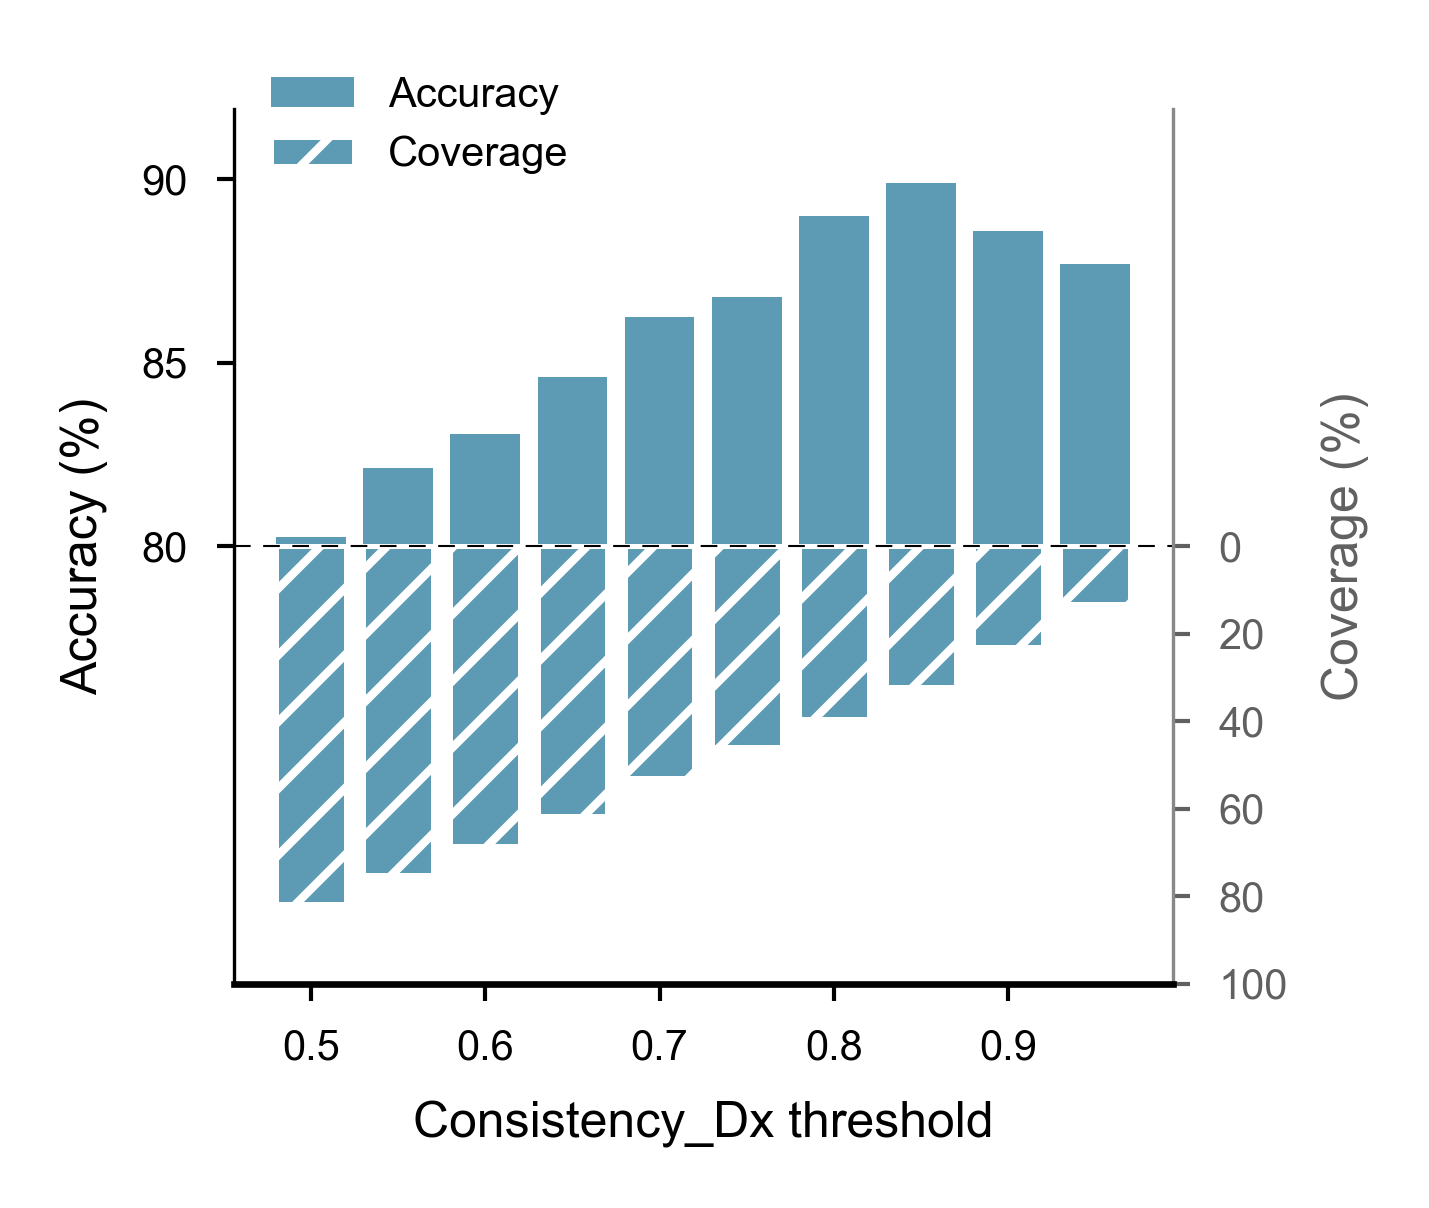

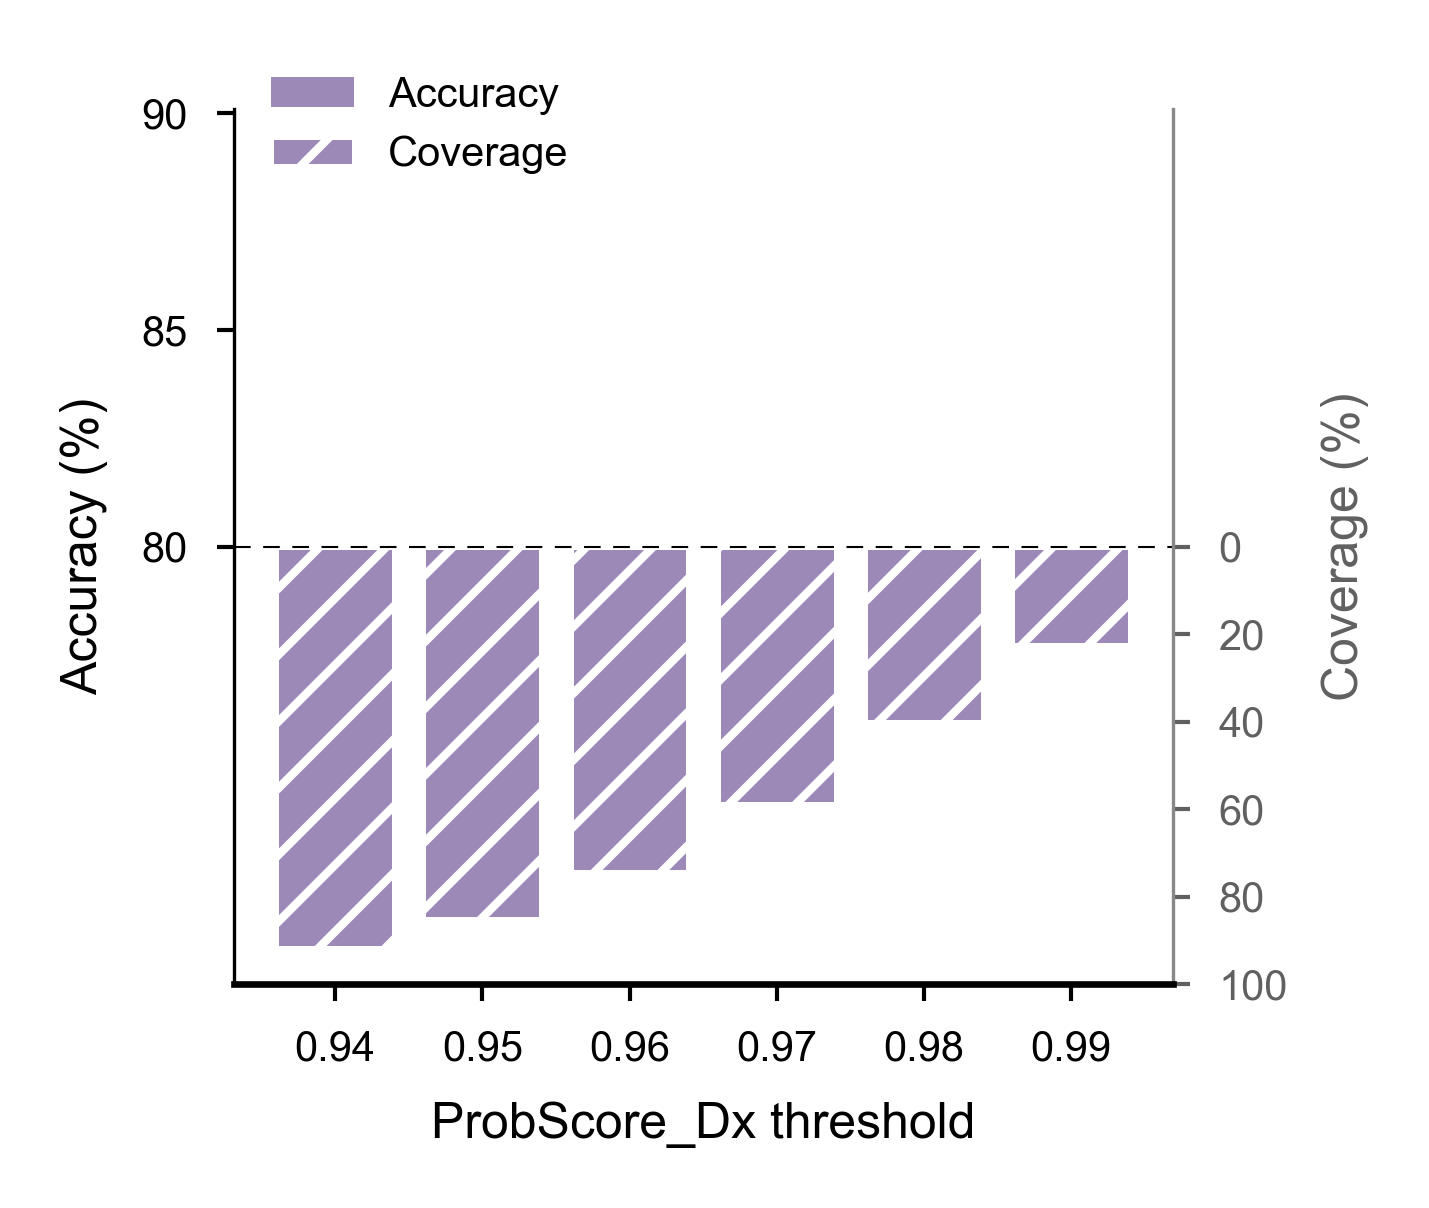

In [ ]:
# --- 1. Load the main data file ---

try:
    df_master =pd.read_csv('/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/84/84.10/master_feature_dataframe.csv')
    
    print(f"✅ Successfully loaded Master DataFrame with {len(df_master)} records.")
except FileNotFoundError:
    print("❌ ERROR: Master DataFrame not found.")
    exit()

# --- 2. Run single-point analysis (optional; retain or comment out) ---
print("\n--- Running Single-Point Threshold Analysis ---")
conf_results = analyze_threshold_performance(
    df=df_master,
    score_column='Consistency_Dx',
    threshold=0.85,
    greater_is_better=True
)
print_results(conf_results)

# --- 3. Run curve analysis ---
print("\n--- Running Threshold Curve Analysis ---")

save_dir = '/mnt/bulk-uranus/lizhang/LiWorkSpace/data/plots/84/84.10/threshold'
os.makedirs(save_dir, exist_ok=True)

# a. Analyze Consistency_Dx
score_to_analyze = 'Consistency_Dx'
print(f"  - Generating curves for '{score_to_analyze}'...")

custom_thresholds = np.arange(0.7, 1.01, 0.05)
# This generates [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

print(f"    - Using custom thresholds: {np.round(custom_thresholds, 2)}")

curves_df = calculate_performance_curves(df_master, score_to_analyze, greater_is_better=True, threshold_range=custom_thresholds)
csv_path = os.path.join(save_dir, f'threshold_curves_{score_to_analyze}.csv')
curves_df.to_csv(csv_path, index=False)
print(f"Saved curve data to: {csv_path}")

plot_tradeoff_bar(curves_df, score_to_analyze, save_dir, bar_color='#5D9BB5')
plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.5)
plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.55)
plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.6)
plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.65)
plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.7)
plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.75)
plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.8)
plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.85)
plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.9)
plot_triage_sankey(df_master, save_dir, score_to_analyze, threshold=0.95)




# # b. (Optional) Analyze other scores.
print("\n--- Running Single-Point Threshold Analysis ---")
conf_results = analyze_threshold_performance(
    df=df_master,
    score_column='ProbScore_Dx',
    threshold=0.85,
    greater_is_better=True
)
print_results(conf_results)

# --- 3. Run curve analysis ---
print("\n--- Running Threshold Curve Analysis ---")

# a. Analyze ProbScore_Dx
score_to_analyze = 'ProbScore_Dx'
print(f"  - Generating curves for '{score_to_analyze}'...")

custom_thresholds = np.arange(0.94, 1.01, 0.01)
# This generates [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

print(f"    - Using custom thresholds: {np.round(custom_thresholds, 2)}")

curves_df = calculate_performance_curves(df_master, score_to_analyze, greater_is_better=True, threshold_range=custom_thresholds)
csv_path = os.path.join(save_dir, f'threshold_curves_{score_to_analyze}.csv')
curves_df.to_csv(csv_path, index=False)
print(f"Saved curve data to: {csv_path}")

plot_tradeoff_bar(curves_df, score_to_analyze, save_dir, bar_color='#9C89B8')


In [ ]:
# Paired-design statistics: runs_N = 3, 5, 10
# Objectives:
# 1) Does the consistency score vary with runs_N（Friedman + Wilcoxon）
# 2) Does coverage (whether the threshold is met) vary with runs_N（Cochran's Q + McNemar）
# 3) Does accuracy (correctness within the covered subset) vary with runs_N（Cochran's Q + McNemar）

import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.contingency_tables import cochrans_q, mcnemar
from statsmodels.stats.multitest import multipletests


def _holm_pairwise(pairs):
    """
    pairs: list of dict with key 'p_raw'
    """
    pvals = [x["p_raw"] for x in pairs]
    reject, p_adj, _, _ = multipletests(pvals, method="holm")
    for i, row in enumerate(pairs):
        row["p_holm"] = p_adj[i]
        row["significant"] = bool(reject[i])
    return pairs


def paired_analysis_runsN(
    df: pd.DataFrame,
    sample_col: str = "sample_id",      # Replace with your unique sample ID column name
    run_col: str = "runs_N",
    score_col: str = "Consistency_Dx",
    correct_col: str = "final_decision", # 0/1, 1=correct
    run_levels=(3, 5, 10),
    threshold=0.85,
):
    """
    只保留 run_levels 内、且三个 run 都存在的样本（完整配对）
    """
    d = df.copy()
    d = d[d[run_col].isin(run_levels)]

    # Ensure every sample has records for all three runs (complete pairing)
    cnt = d.groupby(sample_col)[run_col].nunique()
    keep_ids = cnt[cnt == len(run_levels)].index
    d = d[d[sample_col].isin(keep_ids)].copy()

    # Wide-format tables (one row per sample)
    wide_score = d.pivot(index=sample_col, columns=run_col, values=score_col)
    wide_correct = d.pivot(index=sample_col, columns=run_col, values=correct_col)

    # Fix the column order to run_levels
    wide_score = wide_score.loc[:, run_levels]
    wide_correct = wide_correct.loc[:, run_levels]

    # -------- 1) consistency score: Friedman + Wilcoxon --------
    fr_stat, fr_p = friedmanchisquare(
        wide_score[run_levels[0]].values,
        wide_score[run_levels[1]].values,
        wide_score[run_levels[2]].values,
    )

    score_pairs = []
    for a, b in combinations(run_levels, 2):
        # Paired Wilcoxon; guard against errors from all-zero differences
        diff = wide_score[a] - wide_score[b]
        if np.allclose(diff.values, 0):
            p = 1.0
            stat = 0.0
        else:
            stat, p = wilcoxon(wide_score[a], wide_score[b], zero_method="wilcox", alternative="two-sided")
        score_pairs.append({"run_i": a, "run_j": b, "stat": stat, "p_raw": p})
    score_pairs = _holm_pairwise(score_pairs)
    score_pairwise_df = pd.DataFrame(score_pairs)

    # -------- 2) coverage: Cochran's Q + McNemar --------
    # Coverage definition: score >= threshold
    wide_cov = (wide_score >= threshold).astype(int)

    cq_cov = cochrans_q(wide_cov.values)  # returns object with statistic, pvalue
    cov_pairs = []
    for a, b in combinations(run_levels, 2):
        tab = pd.crosstab(wide_cov[a], wide_cov[b]).reindex(index=[0,1], columns=[0,1], fill_value=0)
        # McNemar for paired binary
        m = mcnemar(tab.values, exact=False, correction=True)
        cov_pairs.append({"run_i": a, "run_j": b, "stat": float(m.statistic), "p_raw": float(m.pvalue)})
    cov_pairs = _holm_pairwise(cov_pairs)
    cov_pairwise_df = pd.DataFrame(cov_pairs)

    # -------- 3) accuracy (within the covered subset): Cochran's Q + McNemar --------
    # Definition: evaluate correctness only for samples with coverage = 1.
    # Set uncovered samples to NaN, then retain only samples covered in all three groups for paired comparison
    wide_acc = wide_correct.where(wide_cov == 1, np.nan)

    acc_complete = wide_acc.dropna(axis=0, how="any")
    # Return an empty result when there are no comparable samples
    if len(acc_complete) == 0:
        acc_global = {"statistic": np.nan, "pvalue": np.nan, "n_complete": 0}
        acc_pairwise_df = pd.DataFrame(columns=["run_i", "run_j", "stat", "p_raw", "p_holm", "significant"])
    else:
        acc_bin = acc_complete.astype(int)
        cq_acc = cochrans_q(acc_bin.values)

        acc_pairs = []
        for a, b in combinations(run_levels, 2):
            tab = pd.crosstab(acc_bin[a], acc_bin[b]).reindex(index=[0,1], columns=[0,1], fill_value=0)
            m = mcnemar(tab.values, exact=False, correction=True)
            acc_pairs.append({"run_i": a, "run_j": b, "stat": float(m.statistic), "p_raw": float(m.pvalue)})
        acc_pairs = _holm_pairwise(acc_pairs)
        acc_pairwise_df = pd.DataFrame(acc_pairs)
        acc_global = {"statistic": float(cq_acc.statistic), "pvalue": float(cq_acc.pvalue), "n_complete": len(acc_complete)}

    # Summary table (descriptive statistics)
    summary = []
    n_total = len(wide_score)
    for r in run_levels:
        cov_rate = wide_cov[r].mean()
        # Standard accuracy definition: correctness rate within the covered subset for this run
        covered = wide_cov[r] == 1
        acc_rate = wide_correct.loc[covered, r].mean() if covered.sum() > 0 else np.nan
        summary.append({
            "runs_N": r,
            "n_paired_total": n_total,
            "coverage_rate": cov_rate,
            "accuracy_on_covered": acc_rate,
            "n_covered": int(covered.sum()),
        })
    summary_df = pd.DataFrame(summary)

    out = {
        "summary": summary_df,
        "consistency_global_friedman": {"statistic": float(fr_stat), "pvalue": float(fr_p), "n": n_total},
        "consistency_pairwise_wilcoxon": score_pairwise_df,
        "coverage_global_cochranQ": {"statistic": float(cq_cov.statistic), "pvalue": float(cq_cov.pvalue), "n": n_total},
        "coverage_pairwise_mcnemar": cov_pairwise_df,
        "accuracy_global_cochranQ_on_covered_intersection": acc_global,
        "accuracy_pairwise_mcnemar_on_covered_intersection": acc_pairwise_df,
        "wide_score": wide_score,
        "wide_coverage": wide_cov,
        "wide_correct": wide_correct,
    }
    return out


# =========================
# Example usage
# =========================
import pandas as pd

df3 = pd.read_csv("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/3runs/63.10/master_feature_dataframe.csv")
df5 = pd.read_csv("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10/master_feature_dataframe.csv")
df10 = pd.read_csv("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/10runs_63_104/63.10/master_feature_dataframe.csv")

# If the table has no runs_N column and the 3/5/10 runs come from separate files, concatenate them and add runs_N first
# This is an example; skip it if runs_N already exists in one table
df3["runs_N"]=3; df5["runs_N"]=5; df10["runs_N"]=10
df_master = pd.concat([df3, df5, df10], ignore_index=True)

# Important: convert values to 0/1 for statistical tests
df_master["final_decision"] = df_master["final_decision"].astype(str).str.lower().map({"true": 1, "false": 0})

# Optional: check for values that could not be mapped
if df_master["final_decision"].isna().any():
    print("Warning: final_decision 有未识别值：")
    print(df_master.loc[df_master["final_decision"].isna(), "final_decision"].head())

dup = (
    df_master.groupby(["hadm_id", "runs_N"])
    .size()
    .reset_index(name="n")
    .query("n > 1")
)
print("重复 (hadm_id, runs_N) 数量:", len(dup))

# res = paired_analysis_runsN(
#     df_master,
#     sample_col="hadm_id",
#     run_col="runs_N",
#     score_col="Consistency_Dx",
#     correct_col="final_decision",
#     run_levels=(3,5,10),
#     threshold=0.85
# )

# print(res["summary"])
# print(res["consistency_global_friedman"])
# print(res["coverage_global_cochranQ"])
# print(res["accuracy_global_cochranQ_on_covered_intersection"])

thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
rows = []
for th in thresholds:
    r = paired_analysis_runsN(
        df_master,
        sample_col="hadm_id",
        run_col="runs_N",
        score_col="Consistency_Dx",
        correct_col="final_decision",
        run_levels=(3,5,10),
        threshold=th
    )

    s = r["summary"].set_index("runs_N")

    rows.append({
        "threshold": th,
        "p_consistency_friedman": r["consistency_global_friedman"]["pvalue"],
        "coverage_N3": s.loc[3, "coverage_rate"],
        "coverage_N5": s.loc[5, "coverage_rate"],
        "coverage_N10": s.loc[10, "coverage_rate"],
        "p_coverage_cochranQ": r["coverage_global_cochranQ"]["pvalue"],
        "accuracy_N3": s.loc[3, "accuracy_on_covered"],
        "accuracy_N5": s.loc[5, "accuracy_on_covered"],
        "accuracy_N10": s.loc[10, "accuracy_on_covered"],
        "p_accuracy_cochranQ_on_covered_intersection": r["accuracy_global_cochranQ_on_covered_intersection"]["pvalue"],
        "n_paired": r["consistency_global_friedman"]["n"],
        "n_acc_complete": r["accuracy_global_cochranQ_on_covered_intersection"]["n_complete"],
    })

out_df = pd.DataFrame(rows).sort_values("threshold")

cols_round3 = [
    "coverage_N3",
    "coverage_N5",
    "coverage_N10",
    "accuracy_N3",
    "accuracy_N5",
    "accuracy_N10"
]
for c in cols_round3:
    out_df[c] = pd.to_numeric(out_df[c], errors="coerce").round(3)

cols_round4 = [
    "p_consistency_friedman",
    "p_coverage_cochranQ",
    "p_accuracy_cochranQ_on_covered_intersection",
]

def fmt_p(x):
    if pd.isna(x):
        return ""
    x = float(x)
    if x < 1e-3:
        return f"{x:.3e}"   # e.g., 1.598e-08
    return f"{x:.3f}"       # Standard decimal notation

for c in cols_round4:
    out_df[c] = pd.to_numeric(out_df[c], errors="coerce").map(fmt_p)


out_path = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/63.10_N/threshold_stats_summary.csv"
out_df.to_csv(out_path, index=False)
print(f"saved: {out_path}")


In [101]:
import os
import pandas as pd

base_dir = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10"

paths = {
    3: f"{base_dir}/63.10_3runs/threshold/threshold_curves_Consistency_Dx.csv",
    5: f"{base_dir}/63.10_5runs/threshold/threshold_curves_Consistency_Dx.csv",
    10: f"{base_dir}/63.10_10runs/threshold/threshold_curves_Consistency_Dx.csv",
}

out_dir = f"{base_dir}/63.10_N"
os.makedirs(out_dir, exist_ok=True)
out_path = f"{out_dir}/overall_threshold_accuracy_coverage_ci.csv"


def fmt3(x):
    if pd.isna(x):
        return ""
    return f"{float(x):.3f}"


def extract_overall(path, runs_n):
    df = pd.read_csv(path)

    overall = df[df["dataset"] == "Overall"].copy()
    if overall.empty:
        raise ValueError(f"No Overall rows found in: {path}")

    keep_cols = [
        "threshold",
        "accuracy",
        "accuracy_ci_lower",
        "accuracy_ci_upper",
        "coverage",
        "coverage_ci_lower",
        "coverage_ci_upper",
    ]
    overall = overall[keep_cols].copy()
    overall["runs_N"] = runs_n

    overall["accuracy"] = overall["accuracy"].map(fmt3)
    overall["accuracy_95CI"] = overall.apply(
        lambda r: f"[{fmt3(r['accuracy_ci_lower'])}, {fmt3(r['accuracy_ci_upper'])}]",
        axis=1,
    )

    overall["coverage"] = overall["coverage"].map(fmt3)
    overall["coverage_95CI"] = overall.apply(
        lambda r: f"[{fmt3(r['coverage_ci_lower'])}, {fmt3(r['coverage_ci_upper'])}]",
        axis=1,
    )

    return overall[
        [
            "threshold",
            "runs_N",
            "accuracy",
            "accuracy_95CI",
            "coverage",
            "coverage_95CI",
        ]
    ]


out_df = pd.concat(
    [extract_overall(path, runs_n) for runs_n, path in paths.items()],
    ignore_index=True,
)

out_df["threshold"] = pd.to_numeric(out_df["threshold"], errors="coerce").round(2)
out_df = out_df.sort_values(["threshold", "runs_N"]).reset_index(drop=True)

out_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(out_df.head())


Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/63.10_N/overall_threshold_accuracy_coverage_ci.csv
   threshold  runs_N accuracy   accuracy_95CI coverage   coverage_95CI
0       0.50       3    0.913  [0.886, 0.934]    0.958  [0.938, 0.972]
1       0.50       5    0.927  [0.901, 0.946]    0.964  [0.945, 0.976]
2       0.50      10    0.914  [0.887, 0.935]    0.969  [0.951, 0.981]
3       0.55       3    0.926  [0.900, 0.946]    0.931  [0.907, 0.949]
4       0.55       5    0.938  [0.914, 0.956]    0.944  [0.921, 0.960]


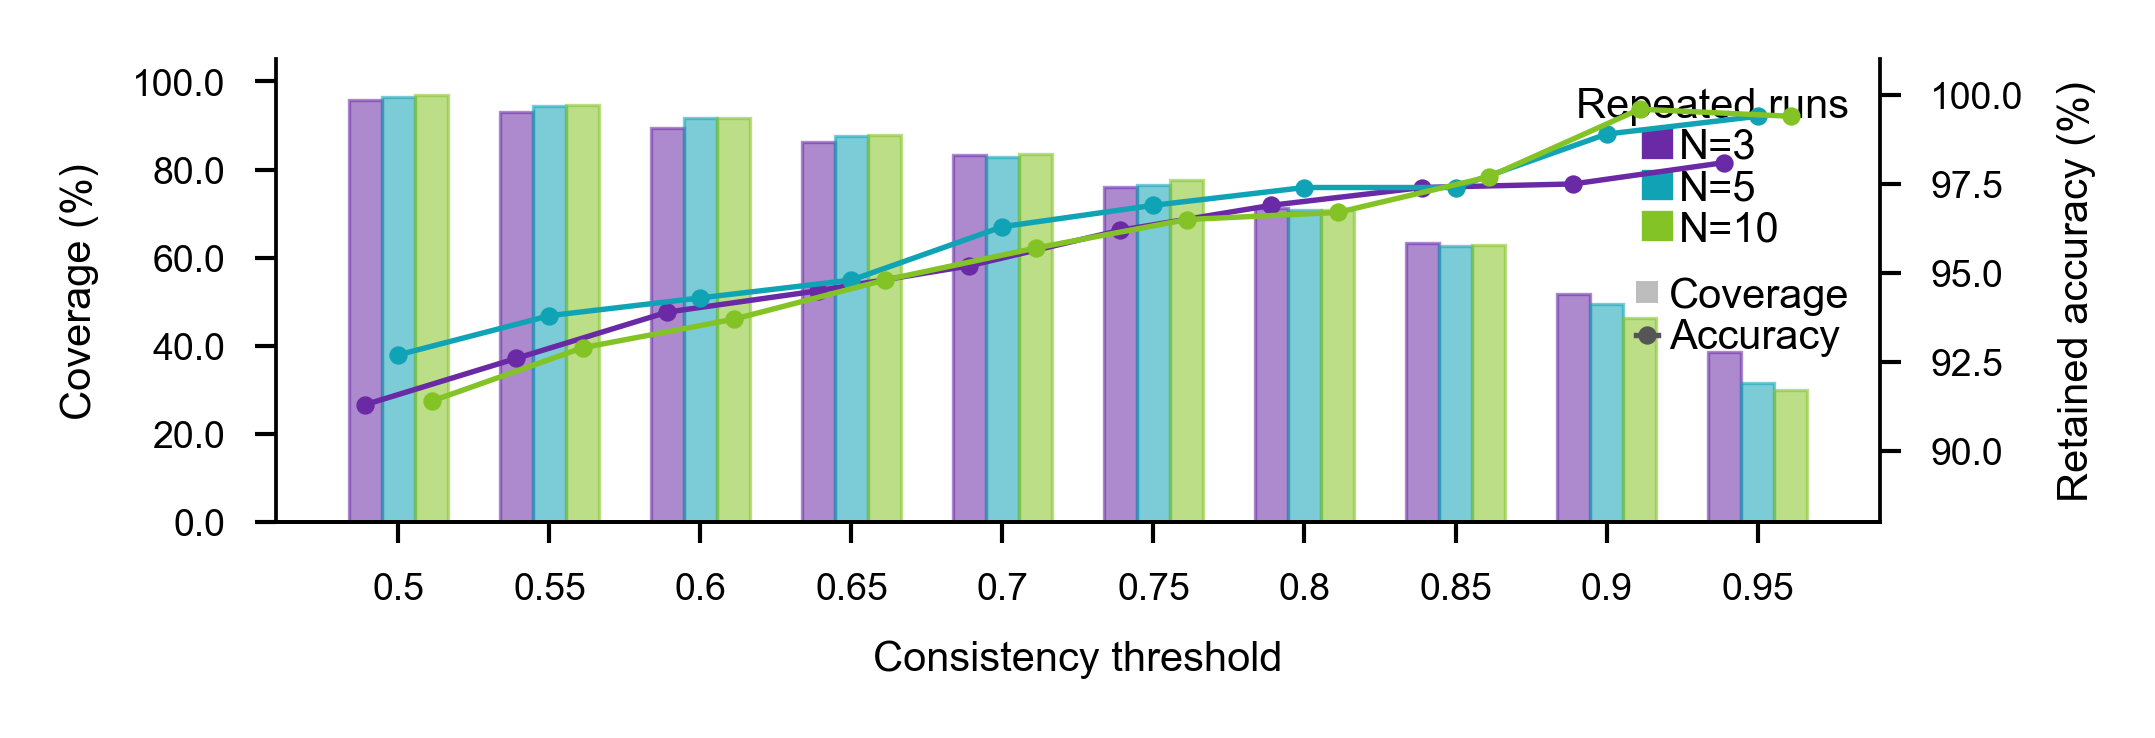

Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/63.10_N/runsN_threshold_coverage_accuracy.svg
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/63.10_N/runsN_threshold_coverage_accuracy.pdf
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/63.10_N/runsN_threshold_coverage_accuracy.png


In [81]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
import matplotlib.font_manager as fm

# =========================
# Paths
# =========================
in_path = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/63.10_N/threshold_stats_summary.csv"
out_dir = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/63.10_N"
os.makedirs(out_dir, exist_ok=True)

svg_path = os.path.join(out_dir, "runsN_threshold_coverage_accuracy.svg")
pdf_path = os.path.join(out_dir, "runsN_threshold_coverage_accuracy.pdf")
png_path = os.path.join(out_dir, "runsN_threshold_coverage_accuracy.png")

# =========================
# Style
# =========================
try:
    arial_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
    fm.fontManager.addfont(arial_path)
    plt.rcParams["font.family"] = "Arial"
except FileNotFoundError:
    plt.rcParams["font.family"] = "sans-serif"

plt.rcParams.update({
    "font.size": 5,
    "axes.labelsize": 5,
    "axes.titlesize": 6,
    "xtick.labelsize": 4.5,
    "ytick.labelsize": 4.5,
    "legend.fontsize": 4.5,
    "axes.linewidth": 0.45,
    "xtick.major.width": 0.45,
    "ytick.major.width": 0.45,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def mm_to_inch(mm):
    return mm / 25.4

# =========================
# Load data
# =========================
df = pd.read_csv(in_path)
df["threshold"] = pd.to_numeric(df["threshold"], errors="coerce")
df = df.sort_values("threshold").reset_index(drop=True)

runs = ["N3", "N5", "N10"]
labels = {
    "N3": "N=3",
    "N5": "N=5",
    "N10": "N=10",
}

colors = {
    "N3": "#6A2AA5",
    "N5": "#10A3B6",
    "N10": "#84C325",
}

# Convert proportions to percentages
for n in runs:
    df[f"coverage_{n}"] = pd.to_numeric(df[f"coverage_{n}"], errors="coerce") * 100
    df[f"accuracy_{n}"] = pd.to_numeric(df[f"accuracy_{n}"], errors="coerce") * 100

# =========================
# Plot
# =========================
x = np.arange(len(df))
bar_width = 0.22
offsets = {
    "N3": -bar_width,
    "N5": 0.0,
    "N10": bar_width,
}

fig, ax_cov = plt.subplots(figsize=(mm_to_inch(90), mm_to_inch(30)), dpi=600)
ax_acc = ax_cov.twinx()

# Coverage bars
for n in runs:
    ax_cov.bar(
        x + offsets[n],
        df[f"coverage_{n}"],
        width=bar_width,
        color=colors[n],
        alpha=0.55,
        edgecolor=colors[n],
        linewidth=0.4,
        zorder=1,
    )

# Accuracy point-lines
for n in runs:
    ax_acc.plot(
        x + offsets[n],
        df[f"accuracy_{n}"],
        color=colors[n],
        marker="o",
        markersize=1.8,
        markeredgewidth=0.4,
        linewidth=0.65,
        zorder=3,
    )

# Axes
ax_cov.set_xlabel("Consistency threshold")
ax_cov.set_ylabel("Coverage (%)")
ax_acc.set_ylabel("Retained accuracy (%)")

ax_cov.set_xticks(x)
ax_cov.set_xticklabels([f"{v:.2f}".rstrip("0").rstrip(".") for v in df["threshold"]])

ax_cov.set_ylim(0.0, 105)
ax_acc.set_ylim(88, 101)

ax_cov.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
ax_acc.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

# No background grid lines
ax_cov.grid(False)
ax_acc.grid(False)

for ax in [ax_cov, ax_acc]:
    ax.spines["top"].set_visible(False)
    ax.tick_params(length=2.5, width=0.5)

ax_cov.spines["right"].set_visible(False)
ax_acc.spines["left"].set_visible(False)

# Legends
run_handles = [
    Patch(facecolor=colors[n], edgecolor=colors[n], alpha=1.0, label=labels[n])
    for n in runs
]

metric_handles = [
    Patch(facecolor="#BDBDBD", edgecolor="none", alpha=1.0, label="Coverage"),
    Line2D(
        [0], [0],
        color="#555555",
        marker="o",
        linewidth=0.65,
        markersize=1.8,
        markeredgewidth=0.4,
        label="Accuracy",
    ),
]

leg1 = ax_cov.legend(
    handles=run_handles,
    title="Repeated runs",
    frameon=False,
    facecolor="none",
    loc="upper right",
    bbox_to_anchor=(0.995, 0.99),
    handlelength=0.55,
    handleheight=0.45,
    handletextpad=0.25,
    borderpad=0.05,
    labelspacing=0.08,
    columnspacing=0.4,
    title_fontsize=5,
    fontsize=5,
)
ax_cov.add_artist(leg1)

ax_cov.legend(
    handles=metric_handles,
    frameon=False,
    facecolor="none",
    loc="upper right",
    bbox_to_anchor=(0.995, 0.58),
    handlelength=0.55,
    handleheight=0.45,
    handletextpad=0.25,
    borderpad=0.05,
    labelspacing=0.08,
    columnspacing=0.4,
    fontsize=5,
)

fig.tight_layout()

# =========================
# Save
# =========================
fig.savefig(svg_path, format="svg", bbox_inches="tight")
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
fig.savefig(png_path, format="png", bbox_inches="tight", dpi=600)

plt.show()

print(f"Saved: {svg_path}")
print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")


In [100]:
# Paired-design statistics: T = 0.01, 0.3, 0.6, 0.9
# Objectives:
# 1) Does the consistency score vary with T（Friedman + Wilcoxon）
# 2) Does coverage (whether the threshold is met) vary with T（Cochran's Q + McNemar）
# 3) Does accuracy (correctness within the covered subset) vary with T（Cochran's Q + McNemar）

import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.contingency_tables import cochrans_q, mcnemar
from statsmodels.stats.multitest import multipletests


def _holm_pairwise(pairs):
    """
    pairs: list of dict with key 'p_raw'
    """
    pvals = [x["p_raw"] for x in pairs]
    reject, p_adj, _, _ = multipletests(pvals, method="holm")
    for i, row in enumerate(pairs):
        row["p_holm"] = p_adj[i]
        row["significant"] = bool(reject[i])
    return pairs


def paired_analysis_runsN(
    df: pd.DataFrame,
    sample_col: str = "sample_id",      # Replace with your unique sample ID column name
    run_col: str = "runs_N",
    score_col: str = "Consistency_Dx",
    correct_col: str = "final_decision", # 0/1, 1=correct
    run_levels=(3, 5, 10),
    threshold=0.85,
):
    """
    只保留 run_levels 内、且三个 run 都存在的样本（完整配对）
    """
    d = df.copy()
    d = d[d[run_col].isin(run_levels)]

    # Ensure every sample has records for all three runs (complete pairing)
    cnt = d.groupby(sample_col)[run_col].nunique()
    keep_ids = cnt[cnt == len(run_levels)].index
    d = d[d[sample_col].isin(keep_ids)].copy()

    # Wide-format tables (one row per sample)
    wide_score = d.pivot(index=sample_col, columns=run_col, values=score_col)
    wide_correct = d.pivot(index=sample_col, columns=run_col, values=correct_col)

    # Fix the column order to run_levels
    wide_score = wide_score.loc[:, run_levels]
    wide_correct = wide_correct.loc[:, run_levels]

    # -------- 1) consistency score: Friedman + Wilcoxon --------
    fr_stat, fr_p = friedmanchisquare(
        *[wide_score[level].values for level in run_levels]
    )

    score_pairs = []
    for a, b in combinations(run_levels, 2):
        # Paired Wilcoxon; guard against errors from all-zero differences
        diff = wide_score[a] - wide_score[b]
        if np.allclose(diff.values, 0):
            p = 1.0
            stat = 0.0
        else:
            stat, p = wilcoxon(wide_score[a], wide_score[b], zero_method="wilcox", alternative="two-sided")
        score_pairs.append({"run_i": a, "run_j": b, "stat": stat, "p_raw": p})
    score_pairs = _holm_pairwise(score_pairs)
    score_pairwise_df = pd.DataFrame(score_pairs)

    # -------- 2) coverage: Cochran's Q + McNemar --------
    # Coverage definition: score >= threshold
    wide_cov = (wide_score >= threshold).astype(int)

    cq_cov = cochrans_q(wide_cov.values)  # returns object with statistic, pvalue
    cov_pairs = []
    for a, b in combinations(run_levels, 2):
        tab = pd.crosstab(wide_cov[a], wide_cov[b]).reindex(index=[0,1], columns=[0,1], fill_value=0)
        # McNemar for paired binary
        m = mcnemar(tab.values, exact=False, correction=True)
        cov_pairs.append({"run_i": a, "run_j": b, "stat": float(m.statistic), "p_raw": float(m.pvalue)})
    cov_pairs = _holm_pairwise(cov_pairs)
    cov_pairwise_df = pd.DataFrame(cov_pairs)

    # -------- 3) accuracy (within the covered subset): Cochran's Q + McNemar --------
    # Definition: evaluate correctness only for samples with coverage = 1.
    # Set uncovered samples to NaN, then retain only samples covered in all three groups for paired comparison
    wide_acc = wide_correct.where(wide_cov == 1, np.nan)

    acc_complete = wide_acc.dropna(axis=0, how="any")
    # Return an empty result when there are no comparable samples
    if len(acc_complete) == 0:
        acc_global = {"statistic": np.nan, "pvalue": np.nan, "n_complete": 0}
        acc_pairwise_df = pd.DataFrame(columns=["run_i", "run_j", "stat", "p_raw", "p_holm", "significant"])
    else:
        acc_bin = acc_complete.astype(int)
        cq_acc = cochrans_q(acc_bin.values)

        acc_pairs = []
        for a, b in combinations(run_levels, 2):
            tab = pd.crosstab(acc_bin[a], acc_bin[b]).reindex(index=[0,1], columns=[0,1], fill_value=0)
            m = mcnemar(tab.values, exact=False, correction=True)
            acc_pairs.append({"run_i": a, "run_j": b, "stat": float(m.statistic), "p_raw": float(m.pvalue)})
        acc_pairs = _holm_pairwise(acc_pairs)
        acc_pairwise_df = pd.DataFrame(acc_pairs)
        acc_global = {"statistic": float(cq_acc.statistic), "pvalue": float(cq_acc.pvalue), "n_complete": len(acc_complete)}

    # Summary table (descriptive statistics)
    summary = []
    n_total = len(wide_score)
    for r in run_levels:
        cov_rate = wide_cov[r].mean()
        # Standard accuracy definition: correctness rate within the covered subset for this run
        covered = wide_cov[r] == 1
        acc_rate = wide_correct.loc[covered, r].mean() if covered.sum() > 0 else np.nan
        summary.append({
            run_col: r,
            "n_paired_total": n_total,
            "coverage_rate": cov_rate,
            "accuracy_on_covered": acc_rate,
            "n_covered": int(covered.sum()),
        })
    summary_df = pd.DataFrame(summary)

    out = {
        "summary": summary_df,
        "consistency_global_friedman": {"statistic": float(fr_stat), "pvalue": float(fr_p), "n": n_total},
        "consistency_pairwise_wilcoxon": score_pairwise_df,
        "coverage_global_cochranQ": {"statistic": float(cq_cov.statistic), "pvalue": float(cq_cov.pvalue), "n": n_total},
        "coverage_pairwise_mcnemar": cov_pairwise_df,
        "accuracy_global_cochranQ_on_covered_intersection": acc_global,
        "accuracy_pairwise_mcnemar_on_covered_intersection": acc_pairwise_df,
        "wide_score": wide_score,
        "wide_coverage": wide_cov,
        "wide_correct": wide_correct,
    }
    return out


# =========================
# Example usage
# =========================
import pandas as pd

df_001 = pd.read_csv("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10/master_feature_dataframe.csv")
df_03 = pd.read_csv("/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/105/105.10/master_feature_dataframe.csv")
df_06 = pd.read_csv("/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/106/106.10/master_feature_dataframe.csv")
df_09 = pd.read_csv("/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/107/107.10/master_feature_dataframe.csv")

df_001["T"]=0.01; df_03["T"]=0.3; df_06["T"]=0.6; df_09["T"]=0.9
df_master = pd.concat([df_001, df_03, df_06, df_09], ignore_index=True)

# Important: convert values to 0/1 for statistical tests
df_master["final_decision"] = df_master["final_decision"].astype(str).str.lower().map({"true": 1, "false": 0})

# Optional: check for values that could not be mapped
if df_master["final_decision"].isna().any():
    print("Warning: final_decision 有未识别值：")
    print(df_master.loc[df_master["final_decision"].isna(), "final_decision"].head())

dup = (
    df_master.groupby(["hadm_id", "T"])
    .size()
    .reset_index(name="n")
    .query("n > 1")
)
print("重复 (hadm_id, T) 数量:", len(dup))

thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
rows = []
for th in thresholds:
    r = paired_analysis_runsN(
        df_master,
        sample_col="hadm_id",
        run_col="T",
        score_col="Consistency_Dx",
        correct_col="final_decision",
        run_levels=(0.01, 0.3, 0.6, 0.9),
        threshold=th
    )

    s = r["summary"].set_index("T")

    rows.append({
        "threshold": th,
        "p_consistency_friedman": r["consistency_global_friedman"]["pvalue"],
        "coverage_001": s.loc[0.01, "coverage_rate"],
        "coverage_03": s.loc[0.3, "coverage_rate"],
        "coverage_06": s.loc[0.6, "coverage_rate"],
        "coverage_09": s.loc[0.9, "coverage_rate"],
        "p_coverage_cochranQ": r["coverage_global_cochranQ"]["pvalue"],
        "accuracy_001": s.loc[0.01, "accuracy_on_covered"],
        "accuracy_03": s.loc[0.3, "accuracy_on_covered"],
        "accuracy_06": s.loc[0.6, "accuracy_on_covered"],
        "accuracy_09": s.loc[0.9, "accuracy_on_covered"],
        "p_accuracy_cochranQ_on_covered_intersection": r["accuracy_global_cochranQ_on_covered_intersection"]["pvalue"],
        "n_paired": r["consistency_global_friedman"]["n"],
        "n_acc_complete": r["accuracy_global_cochranQ_on_covered_intersection"]["n_complete"],
    })

out_df = pd.DataFrame(rows).sort_values("threshold")

cols_round4 = [
    "p_consistency_friedman",
    "p_coverage_cochranQ",
    "p_accuracy_cochranQ_on_covered_intersection",
]

def fmt_p(x):
    if pd.isna(x):
        return ""
    x = float(x)
    if x < 1e-3:
        return f"{x:.3e}"   # e.g., 1.598e-08
    return f"{x:.3f}"       # Standard decimal notation

for c in cols_round4:
    out_df[c] = pd.to_numeric(out_df[c], errors="coerce").map(fmt_p)


out_path = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/T/threshold_stats_summary.csv"
import os
os.makedirs(os.path.dirname(out_path), exist_ok=True)

out_df.to_csv(out_path, index=False)
print(f"saved: {out_path}")


重复 (hadm_id, T) 数量: 0


/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1412: RuntimeWarning:

invalid value encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning:

divide by zero encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning:

divide by zero encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning:

divide by zero encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning:

divide by zero encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/M

saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/T/threshold_stats_summary.csv


/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1412: RuntimeWarning:

invalid value encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning:

divide by zero encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning:

divide by zero encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning:

divide by zero encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning:

divide by zero encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/M

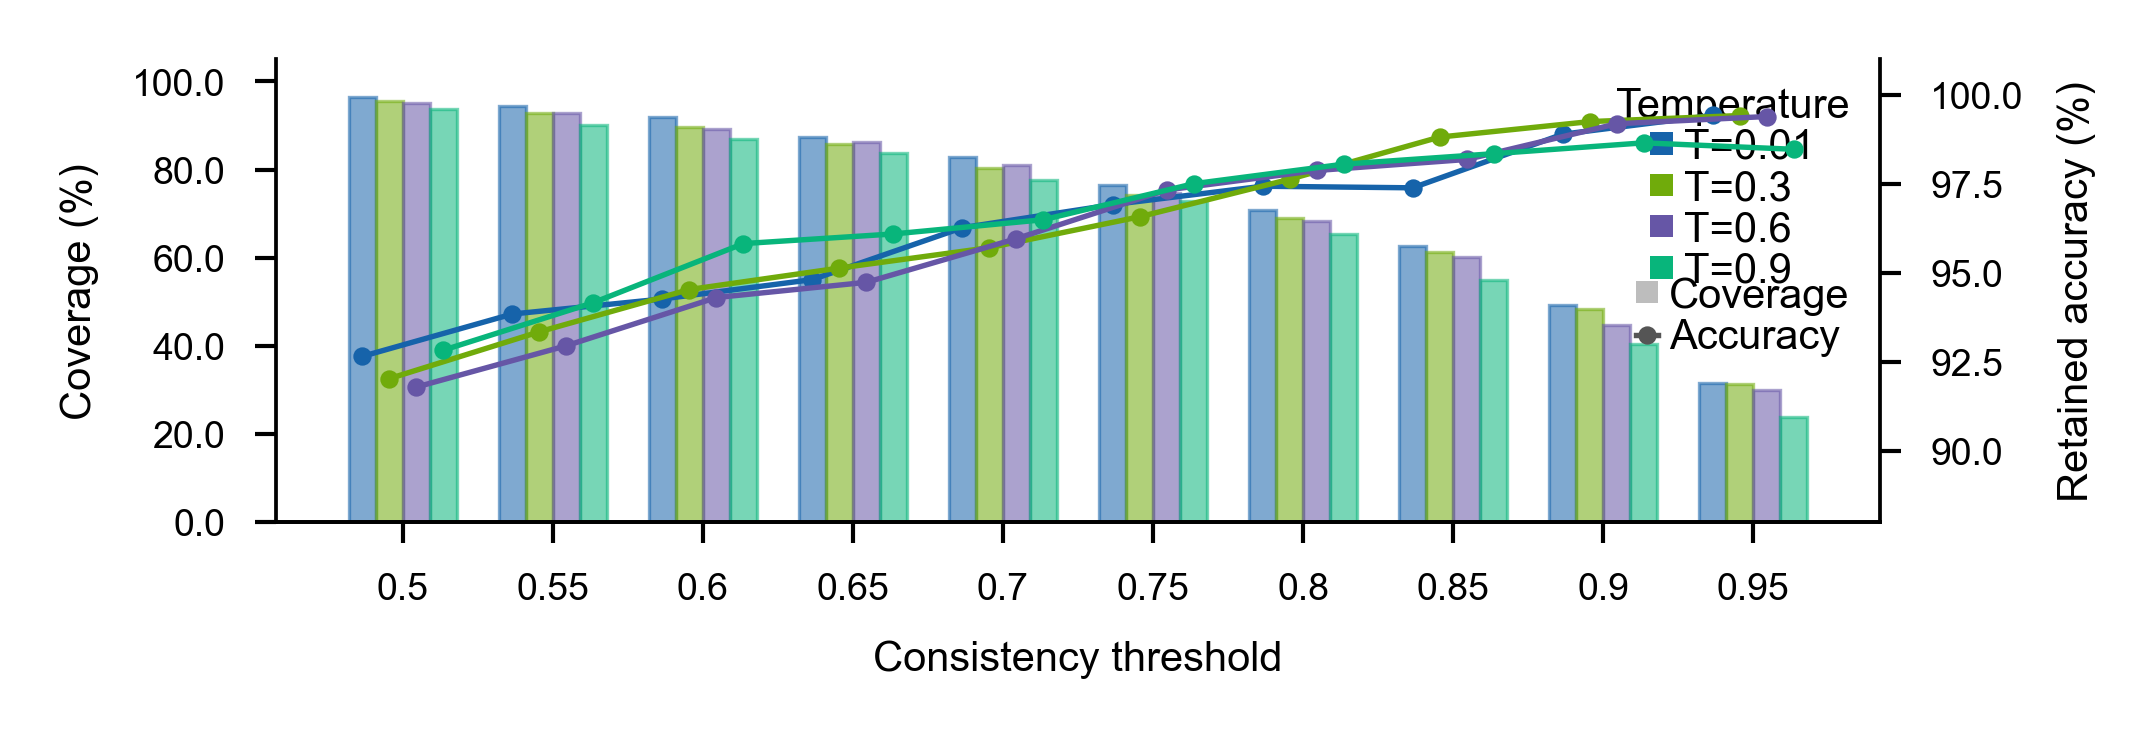

Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/T/temperature_threshold_coverage_accuracy.svg
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/T/temperature_threshold_coverage_accuracy.pdf
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/T/temperature_threshold_coverage_accuracy.png


In [82]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
import matplotlib.font_manager as fm

# =========================
# Paths
# =========================
in_path = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/T/threshold_stats_summary.csv"
out_dir = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/T"
os.makedirs(out_dir, exist_ok=True)

svg_path = os.path.join(out_dir, "temperature_threshold_coverage_accuracy.svg")
pdf_path = os.path.join(out_dir, "temperature_threshold_coverage_accuracy.pdf")
png_path = os.path.join(out_dir, "temperature_threshold_coverage_accuracy.png")

# =========================
# Style
# =========================
try:
    arial_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
    fm.fontManager.addfont(arial_path)
    plt.rcParams["font.family"] = "Arial"
except FileNotFoundError:
    plt.rcParams["font.family"] = "sans-serif"

plt.rcParams.update({
    "font.size": 5,
    "axes.labelsize": 5,
    "axes.titlesize": 6,
    "xtick.labelsize": 4.5,
    "ytick.labelsize": 4.5,
    "legend.fontsize": 4.5,
    "axes.linewidth": 0.45,
    "xtick.major.width": 0.45,
    "ytick.major.width": 0.45,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def mm_to_inch(mm):
    return mm / 25.4

# =========================
# Load data
# =========================
df = pd.read_csv(in_path)
df["threshold"] = pd.to_numeric(df["threshold"], errors="coerce")
df = df.sort_values("threshold").reset_index(drop=True)

temperatures = ["001", "03", "06", "09"]
labels = {
    "001": "T=0.01",
    "03": "T=0.3",
    "06": "T=0.6",
    "09": "T=0.9",
}

colors = {
    "001": "#1663AA",
    "03": "#70ab0b",
    "06": "#6656A6",
    "09": "#08b57b",
}

# Convert proportions to percentages
for t in temperatures:
    df[f"coverage_{t}"] = pd.to_numeric(df[f"coverage_{t}"], errors="coerce") * 100
    df[f"accuracy_{t}"] = pd.to_numeric(df[f"accuracy_{t}"], errors="coerce") * 100

# =========================
# Plot
# =========================
x = np.arange(len(df))
bar_width = 0.18
offsets = {
    "001": -1.5 * bar_width,
    "03": -0.5 * bar_width,
    "06": 0.5 * bar_width,
    "09": 1.5 * bar_width,
}

fig, ax_cov = plt.subplots(figsize=(mm_to_inch(90), mm_to_inch(30)), dpi=600)
ax_acc = ax_cov.twinx()

# Coverage bars
for t in temperatures:
    ax_cov.bar(
        x + offsets[t],
        df[f"coverage_{t}"],
        width=bar_width,
        color=colors[t],
        alpha=0.55,
        edgecolor=colors[t],
        linewidth=0.4,
        zorder=1,
    )

# Accuracy point-lines
for t in temperatures:
    ax_acc.plot(
        x + offsets[t],
        df[f"accuracy_{t}"],
        color=colors[t],
        marker="o",
        markersize=1.8,
        markeredgewidth=0.4,
        linewidth=0.65,
        zorder=3,
    )

# Axes
ax_cov.set_xlabel("Consistency threshold")
ax_cov.set_ylabel("Coverage (%)")
ax_acc.set_ylabel("Retained accuracy (%)")

ax_cov.set_xticks(x)
ax_cov.set_xticklabels([f"{v:.2f}".rstrip("0").rstrip(".") for v in df["threshold"]])

ax_cov.set_ylim(0.0, 105)
ax_acc.set_ylim(88, 101)

ax_cov.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
ax_acc.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

# No background grid lines
ax_cov.grid(False)
ax_acc.grid(False)

for ax in [ax_cov, ax_acc]:
    ax.spines["top"].set_visible(False)
    ax.tick_params(length=2.5, width=0.5)

ax_cov.spines["right"].set_visible(False)
ax_acc.spines["left"].set_visible(False)

# Legends
temperature_handles = [
    Patch(facecolor=colors[t], edgecolor="none", alpha=1.0, label=labels[t])
    for t in temperatures
]

metric_handles = [
    Patch(facecolor="#BDBDBD", edgecolor="none", alpha=1.0, label="Coverage"),
    Line2D(
        [0], [0],
        color="#555555",
        marker="o",
        linewidth=0.65,
        markersize=1.8,
        markeredgewidth=0.4,
        label="Accuracy",
    ),
]

leg1 = ax_cov.legend(
    handles=temperature_handles,
    title="Temperature",
    frameon=False,
    facecolor="none",
    loc="upper right",
    bbox_to_anchor=(0.995, 0.99),
    handlelength=0.55,
    handleheight=0.45,
    handletextpad=0.25,
    borderpad=0.05,
    labelspacing=0.08,
    columnspacing=0.4,
    title_fontsize=5,
    fontsize=5,
)
ax_cov.add_artist(leg1)

ax_cov.legend(
    handles=metric_handles,
    frameon=False,
    facecolor="none",
    loc="upper right",
    bbox_to_anchor=(0.995, 0.58),
    handlelength=0.55,
    handleheight=0.45,
    handletextpad=0.25,
    borderpad=0.05,
    labelspacing=0.08,
    columnspacing=0.4,
    fontsize=5,
)

fig.tight_layout()

# =========================
# Save
# =========================
fig.savefig(svg_path, format="svg", bbox_inches="tight")
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
fig.savefig(png_path, format="png", bbox_inches="tight", dpi=600)

plt.show()

print(f"Saved: {svg_path}")
print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")


In [99]:
import os
import pandas as pd

base_dir = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10"

paths = {
    0.01: "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/63.10_5runs/threshold/threshold_curves_Consistency_Dx.csv",
    0.3: "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/plots/105/105.10/threshold/threshold_curves_Consistency_Dx.csv",
    0.6: "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/plots/106/106.10/threshold/threshold_curves_Consistency_Dx.csv",
    0.9: "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/plots/107/107.10/threshold/threshold_curves_Consistency_Dx.csv",
}

out_dir = f"{base_dir}/T"
os.makedirs(out_dir, exist_ok=True)
out_path = f"{out_dir}/overall_threshold_accuracy_coverage_ci.csv"


def fmt3(x):
    if pd.isna(x):
        return ""
    return f"{float(x):.3f}"


def extract_overall(path, T):
    df = pd.read_csv(path)

    overall = df[df["dataset"] == "Overall"].copy()
    if overall.empty:
        raise ValueError(f"No Overall rows found in: {path}")

    keep_cols = [
        "threshold",
        "accuracy",
        "accuracy_ci_lower",
        "accuracy_ci_upper",
        "coverage",
        "coverage_ci_lower",
        "coverage_ci_upper",
    ]
    overall = overall[keep_cols].copy()
    overall["T"] = T

    overall["accuracy"] = overall["accuracy"].map(fmt3)
    overall["accuracy_95CI"] = overall.apply(
        lambda r: f"[{fmt3(r['accuracy_ci_lower'])}, {fmt3(r['accuracy_ci_upper'])}]",
        axis=1,
    )

    overall["coverage"] = overall["coverage"].map(fmt3)
    overall["coverage_95CI"] = overall.apply(
        lambda r: f"[{fmt3(r['coverage_ci_lower'])}, {fmt3(r['coverage_ci_upper'])}]",
        axis=1,
    )

    return overall[
        [
            "threshold",
            "T",
            "accuracy",
            "accuracy_95CI",
            "coverage",
            "coverage_95CI",
        ]
    ]


out_df = pd.concat(
    [extract_overall(path, T) for T, path in paths.items()],
    ignore_index=True,
)

out_df["threshold"] = pd.to_numeric(out_df["threshold"], errors="coerce").round(2)
out_df = out_df.sort_values(["threshold", "T"]).reset_index(drop=True)

out_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(out_df.head())


Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/T/overall_threshold_accuracy_coverage_ci.csv
   threshold     T accuracy   accuracy_95CI coverage   coverage_95CI
0       0.50  0.01    0.927  [0.901, 0.946]    0.964  [0.945, 0.976]
1       0.50  0.30    0.920  [0.894, 0.941]    0.956  [0.936, 0.971]
2       0.50  0.60    0.918  [0.891, 0.939]    0.951  [0.930, 0.966]
3       0.50  0.90    0.928  [0.903, 0.948]    0.936  [0.913, 0.954]
4       0.55  0.01    0.938  [0.914, 0.956]    0.944  [0.921, 0.960]


In [92]:
# Paired-design statistics: embedding mode: all-MiniLM-L6-v2, all-mpnet-base-v2, bge-base-en-v1.5
# Objectives:
# 1) Does the consistency score vary with embed（Friedman + Wilcoxon）
# 2) Does coverage (whether the threshold is met) vary with embed（Cochran's Q + McNemar）
# 3) Does accuracy (correctness within the covered subset) vary with embed（Cochran's Q + McNemar）

import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.contingency_tables import cochrans_q, mcnemar
from statsmodels.stats.multitest import multipletests


def _holm_pairwise(pairs):
    """
    pairs: list of dict with key 'p_raw'
    """
    pvals = [x["p_raw"] for x in pairs]
    reject, p_adj, _, _ = multipletests(pvals, method="holm")
    for i, row in enumerate(pairs):
        row["p_holm"] = p_adj[i]
        row["significant"] = bool(reject[i])
    return pairs


def paired_analysis_runsN(
    df: pd.DataFrame,
    sample_col: str = "sample_id",      # Replace with your unique sample ID column name
    run_col: str = "embed",
    score_col: str = "Consistency_Dx",
    correct_col: str = "final_decision", # 0/1, 1=correct
    run_levels=("MiniLM", "mpnet", "bge"),
    threshold=0.85,
):
    """
    只保留 run_levels 内、且三个 run 都存在的样本（完整配对）
    """
    d = df.copy()
    d = d[d[run_col].isin(run_levels)]

    # Ensure every sample has records for all three runs (complete pairing)
    cnt = d.groupby(sample_col)[run_col].nunique()
    keep_ids = cnt[cnt == len(run_levels)].index
    d = d[d[sample_col].isin(keep_ids)].copy()

    # Wide-format tables (one row per sample)
    wide_score = d.pivot(index=sample_col, columns=run_col, values=score_col)
    wide_correct = d.pivot(index=sample_col, columns=run_col, values=correct_col)

    # Fix the column order to run_levels
    wide_score = wide_score.loc[:, run_levels]
    wide_correct = wide_correct.loc[:, run_levels]

    # -------- 1) consistency score: Friedman + Wilcoxon --------
    fr_stat, fr_p = friedmanchisquare(
        wide_score[run_levels[0]].values,
        wide_score[run_levels[1]].values,
        wide_score[run_levels[2]].values,
    )

    score_pairs = []
    for a, b in combinations(run_levels, 2):
        # Paired Wilcoxon; guard against errors from all-zero differences
        diff = wide_score[a] - wide_score[b]
        if np.allclose(diff.values, 0):
            p = 1.0
            stat = 0.0
        else:
            stat, p = wilcoxon(wide_score[a], wide_score[b], zero_method="wilcox", alternative="two-sided")
        score_pairs.append({"run_i": a, "run_j": b, "stat": stat, "p_raw": p})
    score_pairs = _holm_pairwise(score_pairs)
    score_pairwise_df = pd.DataFrame(score_pairs)

    # -------- 2) coverage: Cochran's Q + McNemar --------
    # Coverage definition: score >= threshold
    wide_cov = (wide_score >= threshold).astype(int)

    cq_cov = cochrans_q(wide_cov.values)  # returns object with statistic, pvalue
    cov_pairs = []
    for a, b in combinations(run_levels, 2):
        tab = pd.crosstab(wide_cov[a], wide_cov[b]).reindex(index=[0,1], columns=[0,1], fill_value=0)
        # McNemar for paired binary
        m = mcnemar(tab.values, exact=False, correction=True)
        cov_pairs.append({"run_i": a, "run_j": b, "stat": float(m.statistic), "p_raw": float(m.pvalue)})
    cov_pairs = _holm_pairwise(cov_pairs)
    cov_pairwise_df = pd.DataFrame(cov_pairs)

    # -------- 3) accuracy (within the covered subset): Cochran's Q + McNemar --------
    # Definition: evaluate correctness only for samples with coverage = 1.
    # Set uncovered samples to NaN, then retain only samples covered in all three groups for paired comparison
    wide_acc = wide_correct.where(wide_cov == 1, np.nan)

    acc_complete = wide_acc.dropna(axis=0, how="any")
    # Return an empty result when there are no comparable samples
    if len(acc_complete) == 0:
        acc_global = {"statistic": np.nan, "pvalue": np.nan, "n_complete": 0}
        acc_pairwise_df = pd.DataFrame(columns=["run_i", "run_j", "stat", "p_raw", "p_holm", "significant"])
    else:
        acc_bin = acc_complete.astype(int)
        cq_acc = cochrans_q(acc_bin.values)

        acc_pairs = []
        for a, b in combinations(run_levels, 2):
            tab = pd.crosstab(acc_bin[a], acc_bin[b]).reindex(index=[0,1], columns=[0,1], fill_value=0)
            m = mcnemar(tab.values, exact=False, correction=True)
            acc_pairs.append({"run_i": a, "run_j": b, "stat": float(m.statistic), "p_raw": float(m.pvalue)})
        acc_pairs = _holm_pairwise(acc_pairs)
        acc_pairwise_df = pd.DataFrame(acc_pairs)
        acc_global = {"statistic": float(cq_acc.statistic), "pvalue": float(cq_acc.pvalue), "n_complete": len(acc_complete)}

    # Summary table (descriptive statistics)
    summary = []
    n_total = len(wide_score)
    for r in run_levels:
        cov_rate = wide_cov[r].mean()
        # Standard accuracy definition: correctness rate within the covered subset for this run
        covered = wide_cov[r] == 1
        acc_rate = wide_correct.loc[covered, r].mean() if covered.sum() > 0 else np.nan
        summary.append({
            "embed": r,
            "n_paired_total": n_total,
            "coverage_rate": cov_rate,
            "accuracy_on_covered": acc_rate,
            "n_covered": int(covered.sum()),
        })
    summary_df = pd.DataFrame(summary)

    out = {
        "summary": summary_df,
        "consistency_global_friedman": {"statistic": float(fr_stat), "pvalue": float(fr_p), "n": n_total},
        "consistency_pairwise_wilcoxon": score_pairwise_df,
        "coverage_global_cochranQ": {"statistic": float(cq_cov.statistic), "pvalue": float(cq_cov.pvalue), "n": n_total},
        "coverage_pairwise_mcnemar": cov_pairwise_df,
        "accuracy_global_cochranQ_on_covered_intersection": acc_global,
        "accuracy_pairwise_mcnemar_on_covered_intersection": acc_pairwise_df,
        "wide_score": wide_score,
        "wide_coverage": wide_cov,
        "wide_correct": wide_correct,
    }
    return out


# =========================
# Example usage
# =========================
import pandas as pd

df_minilm = pd.read_csv("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10/master_feature_dataframe.csv")
df_mpnet = pd.read_csv("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10/mpnet-base/master_feature_dataframe.csv")
df_bge = pd.read_csv("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10/BGE-base/master_feature_dataframe.csv")

# If the table has no embed column and the 3/5/10 runs come from separate files, concatenate them and add embed first
# This is an example; skip it if embed already exists in one table
df_minilm["embed"]="MiniLM"; df_mpnet["embed"]="mpnet"; df_bge["embed"]="bge"
df_master = pd.concat([df_minilm, df_mpnet, df_bge], ignore_index=True)
# Important: convert values to 0/1 for statistical tests
df_master["final_decision"] = df_master["final_decision"].astype(str).str.lower().map({"true": 1, "false": 0})

# Optional: check for values that could not be mapped
if df_master["final_decision"].isna().any():
    print("Warning: final_decision 有未识别值：")
    print(df_master.loc[df_master["final_decision"].isna(), "final_decision"].head())

dup = (
    df_master.groupby(["hadm_id", "embed"])
    .size()
    .reset_index(name="n")
    .query("n > 1")
)
print("重复 (hadm_id, embed) 数量:", len(dup))

thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
rows = []
for th in thresholds:
    r = paired_analysis_runsN(
        df_master,
        sample_col="hadm_id",
        run_col="embed",
        score_col="Consistency_Dx",
        correct_col="final_decision",
        run_levels=("MiniLM", "mpnet", "bge"),
        threshold=th
    )

    s = r["summary"].set_index("embed")

    rows.append({
        "threshold": th,
        "p_consistency_friedman": r["consistency_global_friedman"]["pvalue"],
        "coverage_MiniLM": s.loc["MiniLM", "coverage_rate"],
        "coverage_mpnet": s.loc["mpnet", "coverage_rate"],
        "coverage_bge": s.loc["bge", "coverage_rate"],
        "p_coverage_cochranQ": r["coverage_global_cochranQ"]["pvalue"],
        "accuracy_MiniLM": s.loc["MiniLM", "accuracy_on_covered"],
        "accuracy_mpnet": s.loc["mpnet", "accuracy_on_covered"],
        "accuracy_bge": s.loc["bge", "accuracy_on_covered"],
        "p_accuracy_cochranQ_on_covered_intersection": r["accuracy_global_cochranQ_on_covered_intersection"]["pvalue"],
        "n_paired": r["consistency_global_friedman"]["n"],
        "n_acc_complete": r["accuracy_global_cochranQ_on_covered_intersection"]["n_complete"],
    })

out_df = pd.DataFrame(rows).sort_values("threshold")

cols_round3 = [
    "coverage_MiniLM",
    "coverage_mpnet",
    "coverage_bge",
    "accuracy_MiniLM",
    "accuracy_mpnet",
    "accuracy_bge"
]
for c in cols_round3:
    out_df[c] = pd.to_numeric(out_df[c], errors="coerce").round(3)

cols_round4 = [
    "p_consistency_friedman",
    "p_coverage_cochranQ",
    "p_accuracy_cochranQ_on_covered_intersection",
]

def fmt_p(x):
    if pd.isna(x):
        return ""
    x = float(x)
    if x < 1e-3:
        return f"{x:.3e}"   # e.g., 1.598e-08
    return f"{x:.3f}"       # Standard decimal notation

for c in cols_round4:
    out_df[c] = pd.to_numeric(out_df[c], errors="coerce").map(fmt_p)


out_path = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/embedding_model/threshold_stats_summary.csv"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
out_df.to_csv(out_path, index=False)


重复 (hadm_id, embed) 数量: 0


/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1412: RuntimeWarning:

invalid value encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning:

divide by zero encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning:

divide by zero encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning:

divide by zero encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1412: RuntimeWarning:

invalid value encountered in scalar divide

/mnt/bulk-sirius/lizhang/LiWS/Me

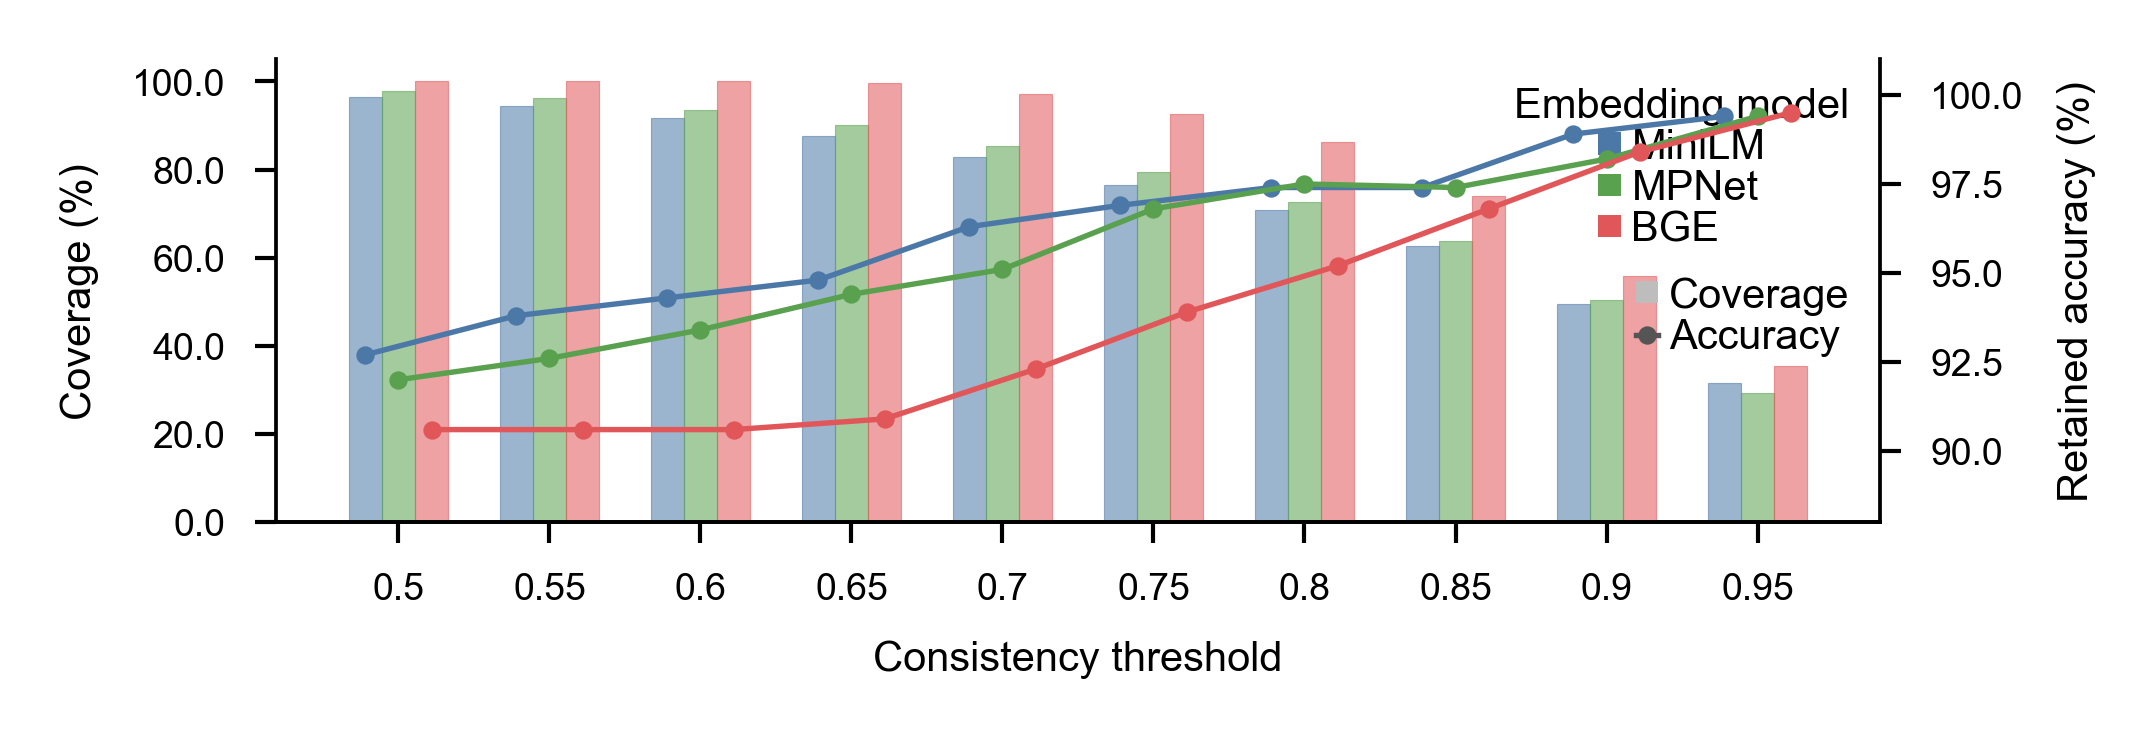

Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/embedding_model/embedding_threshold_coverage_accuracy.svg
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/embedding_model/embedding_threshold_coverage_accuracy.pdf
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/embedding_model/embedding_threshold_coverage_accuracy.png


In [83]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
import matplotlib.font_manager as fm

# =========================
# Paths
# =========================
in_path = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/embedding_model/threshold_stats_summary.csv"
out_dir = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/embedding_model"
os.makedirs(out_dir, exist_ok=True)

svg_path = os.path.join(out_dir, "embedding_threshold_coverage_accuracy.svg")
pdf_path = os.path.join(out_dir, "embedding_threshold_coverage_accuracy.pdf")
png_path = os.path.join(out_dir, "embedding_threshold_coverage_accuracy.png")

# =========================
# Style
# =========================
try:
    arial_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
    fm.fontManager.addfont(arial_path)
    plt.rcParams["font.family"] = "Arial"
except FileNotFoundError:
    plt.rcParams["font.family"] = "sans-serif"

plt.rcParams.update({
    "font.size": 5,
    "axes.labelsize": 5,
    "axes.titlesize": 6,
    "xtick.labelsize": 4.5,
    "ytick.labelsize": 4.5,
    "legend.fontsize": 4.5,
    "axes.linewidth": 0.45,
    "xtick.major.width": 0.45,
    "ytick.major.width": 0.45,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def mm_to_inch(mm):
    return mm / 25.4

# =========================
# Load data
# =========================
df = pd.read_csv(in_path)
df["threshold"] = pd.to_numeric(df["threshold"], errors="coerce")
df = df.sort_values("threshold").reset_index(drop=True)

embeddings = ["MiniLM", "mpnet", "bge"]

labels = {
    "MiniLM": "MiniLM",
    "mpnet": "MPNet",
    "bge": "BGE",
}

colors = {
    "MiniLM": "#4C78A8",
    "mpnet": "#59A14F",
    "bge": "#E15759",
}

# Convert proportions to percentages
for emb in embeddings:
    df[f"coverage_{emb}"] = pd.to_numeric(df[f"coverage_{emb}"], errors="coerce") * 100
    df[f"accuracy_{emb}"] = pd.to_numeric(df[f"accuracy_{emb}"], errors="coerce") * 100

# =========================
# Plot
# =========================
x = np.arange(len(df))
bar_width = 0.22
offsets = {
    "MiniLM": -bar_width,
    "mpnet": 0.0,
    "bge": bar_width,
}

fig, ax_cov = plt.subplots(figsize=(mm_to_inch(90), mm_to_inch(30)), dpi=600)
ax_acc = ax_cov.twinx()

# Coverage bars
for emb in embeddings:
    ax_cov.bar(
        x + offsets[emb],
        df[f"coverage_{emb}"],
        width=bar_width,
        color=colors[emb],
        alpha=0.55,
        edgecolor=colors[emb],
        linewidth=0.14,
        zorder=1,
    )

# Accuracy point-lines
for emb in embeddings:
    ax_acc.plot(
        x + offsets[emb],
        df[f"accuracy_{emb}"],
        color=colors[emb],
        marker="o",
        markersize=1.8,
        markeredgewidth=0.4,
        linewidth=0.65,
        zorder=3,
    )

# Axes
ax_cov.set_xlabel("Consistency threshold")
ax_cov.set_ylabel("Coverage (%)")
ax_acc.set_ylabel("Retained accuracy (%)")

ax_cov.set_xticks(x)
ax_cov.set_xticklabels([f"{v:.2f}".rstrip("0").rstrip(".") for v in df["threshold"]])

ax_cov.set_ylim(0.0, 105)
ax_acc.set_ylim(88, 101)

ax_cov.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
ax_acc.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

# No background grid lines
ax_cov.grid(False)
ax_acc.grid(False)

for ax in [ax_cov, ax_acc]:
    ax.spines["top"].set_visible(False)
    ax.tick_params(length=2.5, width=0.5)

ax_cov.spines["right"].set_visible(False)
ax_acc.spines["left"].set_visible(False)

# Legends: use opaque handles to avoid halo artifacts
embedding_handles = [
    Patch(facecolor=colors[emb], edgecolor="none", alpha=1.0, label=labels[emb])
    for emb in embeddings
]

metric_handles = [
    Patch(facecolor="#BDBDBD", edgecolor="none", alpha=1.0, label="Coverage"),
    Line2D(
        [0], [0],
        color="#555555",
        marker="o",
        linewidth=0.65,
        markersize=1.8,
        markeredgewidth=0.4,
        label="Accuracy",
    ),
]

leg1 = ax_cov.legend(
    handles=embedding_handles,
    title="Embedding model",
    frameon=False,
    facecolor="none",
    loc="upper right",
    bbox_to_anchor=(0.995, 0.99),
    handlelength=0.55,
    handleheight=0.45,
    handletextpad=0.25,
    borderpad=0.05,
    labelspacing=0.08,
    columnspacing=0.4,
    title_fontsize=5,
    fontsize=5,
)
ax_cov.add_artist(leg1)

ax_cov.legend(
    handles=metric_handles,
    frameon=False,
    facecolor="none",
    loc="upper right",
    bbox_to_anchor=(0.995, 0.58),
    handlelength=0.55,
    handleheight=0.45,
    handletextpad=0.25,
    borderpad=0.05,
    labelspacing=0.08,
    columnspacing=0.4,
    fontsize=5,
)

fig.tight_layout()

# =========================
# Save
# =========================
fig.savefig(svg_path, format="svg", bbox_inches="tight")
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
fig.savefig(png_path, format="png", bbox_inches="tight", dpi=600)

plt.show()

print(f"Saved: {svg_path}")
print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")


In [91]:
import os
import pandas as pd

base_dir = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10"

paths = {
    "MiniLM": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/63.10_5runs/threshold/threshold_curves_Consistency_Dx.csv",
    "mpnet": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/63.10_5runs/mpnet-base/threshold/threshold_curves_Consistency_Dx.csv",
    "bge": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/63.10_5runs/BGE-base/threshold/threshold_curves_Consistency_Dx.csv",
}

out_dir = f"{base_dir}/embedding_model"
os.makedirs(out_dir, exist_ok=True)
out_path = f"{out_dir}/overall_threshold_accuracy_coverage_ci.csv"


def fmt3(x):
    if pd.isna(x):
        return ""
    return f"{float(x):.3f}"


def extract_overall(path, embed):
    df = pd.read_csv(path)

    overall = df[df["dataset"] == "Overall"].copy()
    if overall.empty:
        raise ValueError(f"No Overall rows found in: {path}")

    keep_cols = [
        "threshold",
        "accuracy",
        "accuracy_ci_lower",
        "accuracy_ci_upper",
        "coverage",
        "coverage_ci_lower",
        "coverage_ci_upper",
    ]
    overall = overall[keep_cols].copy()
    overall["embed"] = embed

    overall["accuracy"] = overall["accuracy"].map(fmt3)
    overall["accuracy_95CI"] = overall.apply(
        lambda r: f"[{fmt3(r['accuracy_ci_lower'])}, {fmt3(r['accuracy_ci_upper'])}]",
        axis=1,
    )

    overall["coverage"] = overall["coverage"].map(fmt3)
    overall["coverage_95CI"] = overall.apply(
        lambda r: f"[{fmt3(r['coverage_ci_lower'])}, {fmt3(r['coverage_ci_upper'])}]",
        axis=1,
    )

    return overall[
        [
            "threshold",
            "embed",
            "accuracy",
            "accuracy_95CI",
            "coverage",
            "coverage_95CI",
        ]
    ]


out_df = pd.concat(
    [extract_overall(path, embed) for embed, path in paths.items()],
    ignore_index=True,
)

out_df["threshold"] = pd.to_numeric(out_df["threshold"], errors="coerce").round(2)
out_df = out_df.sort_values(["threshold", "embed"]).reset_index(drop=True)

out_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(out_df.head())


Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/embedding_model/overall_threshold_accuracy_coverage_ci.csv
   threshold   embed accuracy   accuracy_95CI coverage   coverage_95CI
0       0.50  MiniLM    0.927  [0.901, 0.946]    0.964  [0.945, 0.976]
1       0.50     bge    0.906  [0.878, 0.927]    1.000  [0.993, 1.000]
2       0.50   mpnet    0.920  [0.894, 0.940]    0.978  [0.962, 0.987]
3       0.55  MiniLM    0.938  [0.914, 0.956]    0.944  [0.921, 0.960]
4       0.55     bge    0.906  [0.878, 0.927]    1.000  [0.993, 1.000]


In [9]:
# simple version, without plot

import pandas as pd
import numpy as np


def analyze_threshold_performance_for_table(
    df: pd.DataFrame, 
    score_column: str, 
    threshold: float,
    greater_is_better: bool = True
) -> dict:
    """
    分析在给定置信度分数和阈值下，筛选后数据的准确率和覆盖率。

    Args:
        df (pd.DataFrame): 包含所有数据的 Master DataFrame。
        score_column (str): 要用作筛选依据的置信度分数所在的列名
                            (e.g., 'Quantitative_Score', 'Semantic_Score').
        threshold (float): 用于筛选的置信度阈值。
        greater_is_better (bool): 分数的方向性。True表示分数越高越好，
                                  False表示分数越低越好。

    Returns:
        dict: 一个包含详细分析结果的字典。
    """
    
    # --- 1. Filter data by threshold ---
    if greater_is_better:
        filtered_df = df[df[score_column] >= threshold]
    else:
        # For metrics such as redundancy, where lower values are better
        filtered_df = df[df[score_column] <= threshold]

    # --- 2. Initialize result storage ---
    results = {
        'score_column': score_column,
        'threshold': threshold,
        'greater_is_better': greater_is_better,
        'by_dataset': {},
        'overall': {}
    }

    # --- 3. Calculate performance for each individual dataset ---
    # Get all dataset names present in the data
    datasets_in_df = df['dataset'].unique()
    
    for dataset in datasets_in_df:
        # Get this dataset from both the original and filtered DataFrames
        original_subset = df[df['dataset'] == dataset]
        filtered_subset = filtered_df[filtered_df['dataset'] == dataset]

        # Calculate the number and proportion of retained records (coverage)
        retained_count = len(filtered_subset)
        total_count = len(original_subset)
        coverage = retained_count / total_count if total_count > 0 else 0
        
        # Calculate accuracy after filtering.
        if retained_count > 0:
            accuracy = filtered_subset['final_decision'].mean()
            correct_retained_count = int(filtered_subset['final_decision'].sum())
            accuracy_ci_lower, accuracy_ci_upper = compute_wilson_ci(correct_retained_count, retained_count)
        else:
            accuracy = np.nan
            correct_retained_count = 0
            accuracy_ci_lower, accuracy_ci_upper = np.nan, np.nan

        coverage_ci_lower, coverage_ci_upper = compute_wilson_ci(retained_count, total_count)

        results['by_dataset'][dataset] = {
            'accuracy': accuracy,
            'accuracy_ci_lower': accuracy_ci_lower,
            'accuracy_ci_upper': accuracy_ci_upper,
            'retained_count': retained_count,
            'total_count': total_count,
            'coverage': coverage,
            'coverage_ci_lower': coverage_ci_lower,
            'coverage_ci_upper': coverage_ci_upper,
        }
        
    # --- 4. Calculate overall performance ---
    overall_total_count = len(df)
    overall_retained_count = len(filtered_df)
    overall_coverage = overall_retained_count / overall_total_count if overall_total_count > 0 else 0
    
    if overall_retained_count > 0:
        overall_accuracy = filtered_df['final_decision'].mean()
        overall_correct_retained_count = int(filtered_df['final_decision'].sum())
        overall_accuracy_ci_lower, overall_accuracy_ci_upper = compute_wilson_ci(
            overall_correct_retained_count,
            overall_retained_count
        )
    else:
        overall_accuracy = np.nan
        overall_correct_retained_count = 0
        overall_accuracy_ci_lower, overall_accuracy_ci_upper = np.nan, np.nan

    overall_coverage_ci_lower, overall_coverage_ci_upper = compute_wilson_ci(
        overall_retained_count,
        overall_total_count
    )

    results['overall'] = {
        'accuracy': overall_accuracy,
        'accuracy_ci_lower': overall_accuracy_ci_lower,
        'accuracy_ci_upper': overall_accuracy_ci_upper,
        'retained_count': overall_retained_count,
        'total_count': overall_total_count,
        'coverage': overall_coverage,
        'coverage_ci_lower': overall_coverage_ci_lower,
        'coverage_ci_upper': overall_coverage_ci_upper,
    }
    
    return results

def print_results_for_table(results: dict):
    """一个辅助函数，用于美观地打印分析结果。"""
    print("\n" + "="*60)
    print(f"Confidence Threshold Analysis Report")
    print(f"  - Score Column: '{results['score_column']}'")
    print(f"  - Threshold: >= {results['threshold']}" if results['greater_is_better'] else f"  - Threshold: <= {results['threshold']}")
    print("="*60)
    
    print("\n--- Performance by Dataset ---")
    for dataset, data in results['by_dataset'].items():
        print(f"  - {dataset}:")
        if data['retained_count'] > 0:
            print(f"    - Accuracy: {data['accuracy']:.2%}")
        else:
            print(f"    - Accuracy: N/A")
        # print(f"    - Coverage: {data['coverage']:.2%} ({data['retained_count']} / {data['total_count']} records retained)")
        print(
            f"    - Coverage: {data['coverage']:.2%} "
            f"[95% CI {data['coverage_ci_lower']:.2%}–{data['coverage_ci_upper']:.2%}] "
            f"({data['retained_count']} / {data['total_count']} records retained)"
        )

    print("\n--- Overall Performance ---")
    overall_data = results['overall']
    if overall_data['retained_count'] > 0:
        print(f"  - Accuracy: {overall_data['accuracy']:.2%}")
    else:
        print(f"  - Accuracy: N/A")
    # print(f"  - Coverage: {overall_data['coverage']:.2%} ({overall_data['retained_count']} / {overall_data['total_count']} records retained)")
    print(
        f"  - Coverage: {overall_data['coverage']:.2%} "
        f"[95% CI {overall_data['coverage_ci_lower']:.2%}–{overall_data['coverage_ci_upper']:.2%}] "
        f"({overall_data['retained_count']} / {overall_data['total_count']} records retained)"
    )
    print("="*60)


# --- Main program ---
if __name__ == "__main__":
    try:
        df_master =pd.read_csv('/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/63.9/master_feature_dataframe.csv')
        
        print(f"✅ Successfully loaded Master DataFrame with {len(df_master)} records.")
    except FileNotFoundError:
        print("❌ ERROR: Master DataFrame not found.")
        exit()

    # --- 2. Run example analysis ---
    
    # Example 1: analyze Consistency_Score with a threshold of 0.9
    # Retain only cases with consistency score >= 0.9
    for cons_threshold in [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]:
        consistency_results = analyze_threshold_performance_for_table(
            df=df_master,
            score_column='Consistency_Dx',
            threshold=cons_threshold,
            greater_is_better=True
        )
        print_results_for_table(consistency_results)

    # # Example 2: analyze ProbScore_Dx with a threshold of 0.85
    for prob_threshold in [0.94, 0.95, 0.96, 0.97, 0.98, 0.99]:
        semantic_results = analyze_threshold_performance_for_table(
            df=df_master,
            score_column='ProbScore_Dx',
            threshold=prob_threshold,
            greater_is_better=True
        )
        print_results_for_table(semantic_results)




✅ Successfully loaded Master DataFrame with 551 records.

Confidence Threshold Analysis Report
  - Score Column: 'Consistency_Dx'
  - Threshold: >= 0.7

--- Performance by Dataset ---
  - appendicitis:
    - Accuracy: 100.00%
    - Coverage: 95.27% [95% CI 90.56%–97.69%] (141 / 148 records retained)
  - cholecystitis:
    - Accuracy: 91.45%
    - Coverage: 90.70% [95% CI 84.44%–94.60%] (117 / 129 records retained)
  - diverticulitis:
    - Accuracy: 95.83%
    - Coverage: 88.89% [95% CI 77.81%–94.81%] (48 / 54 records retained)
  - pancreatitis:
    - Accuracy: 100.00%
    - Coverage: 80.77% [95% CI 68.10%–89.20%] (42 / 52 records retained)
  - pneumonia:
    - Accuracy: 66.67%
    - Coverage: 51.72% [95% CI 34.43%–68.61%] (15 / 29 records retained)
  - pulmonary_embolism:
    - Accuracy: 98.53%
    - Coverage: 75.56% [95% CI 65.75%–83.27%] (68 / 90 records retained)
  - uti:
    - Accuracy: 100.00%
    - Coverage: 51.02% [95% CI 37.47%–64.43%] (25 / 49 records retained)

--- Overall P